# Прогнозирование спроса в розничной сети

## Шаг 0 — Рамка задачи

Прогнозируем суммарные дневные продажи (offline + online) на уровне `(store_id, item_id, day)` на горизонт 7 дней вперёд (D+1 … D+7, multi-step).

Основная метрика — **WMAPE**: она взвешивает ошибку по объёму продаж и не ломается на нулевых и малых продажах, в отличие от MAPE. Рядом смотрим **MAE** (абсолютная ошибка в штуках, понятная бизнесу) и **bias** ($\sum(\hat{y}-y)$) — систематический перекос, который показывает, в какую сторону модель врёт.

Цена ошибки в данных не задана. Бизнес-логика подсказывает, что перепрогноз (просрочка) обычно дороже недопрогноза (упущенная выручка), но без данных по себестоимости зашивать эту асимметрию в метрику нельзя — иначе выбор любого квантиля будет произвольным. Поэтому метрику оставляем симметричной, а перекос ловим через анализ bias и при необходимости правим бизнес-надстройкой.

Ключевые решения, принятые на старте: сплит только по времени (out-of-time, без random split); глобальная WMAPE как метрика; baseline-лестница от naive к Prophet перед тем, как браться за бустинг; train до 1 сентября 2024 и четыре rolling-окна по 7 дней в сентябре как тест.

## Природа задачи: intermittent demand

Главная сложность здесь не в объёме данных, а в их форме. Спрос на уровне отдельного SKU — **перемежающийся** (intermittent demand): для большинства пар `(store, item)` продажи происходят редко, а между ними идут длинные серии нулей. После наложения продаж на регулярную сетку доля нулевых строк в скелете — около 78% (см. шаг 1.3), и это не дефект данных, а структурное свойство панели «каждый товар × каждый день».

Важно не путать два разных «процента нулей»: нули в скелете — это нормально, и **фильтровать их нельзя** — нулевой день продаж это полноценный сигнал «спроса не было», а не пропуск. Мы убираем только «мёртвый хвост» после выбытия товара (шаг 1.5) и позже, перед обучением, отсекаем целиком неактивные пары `(item, store)` recency-фильтром на 45 дней (шаг 7) — но сами нулевые дни внутри истории живого товара остаются нетронутыми. Оба фильтра режут по парам и хвостам, а не по нулевым дням.

Из-за такой формы ряда классические TS-методы здесь буксуют. Prophet и подобные хорошо описывают гладкий агрегированный ряд (продажи всей сети — отсюда ~7% WMAPE на макроуровне), но рассыпаются на разреженных SKU-рядах: top-down decomposition через статические доли даёт ~59% WMAPE и не бьёт даже среднее четырёх лагов. Это видно по всей baseline-лестнице (шаг 6).

Отсюда и логика проекта: вместо того чтобы пытаться «починить» TS-модель на разреженном ряде, мы переходим к gradient boosting на панели с лагами, rolling-статистиками и экзогенными признаками (промо, цена, календарь). Для intermittent demand это и есть стандартный современный подход — CatBoost использует разреженность и нулевые серии как информацию, а не как помеху. Альтернативы вроде Croston / SBA или zero-inflated моделей остаются за рамками: при наличии богатых экзогенных фич бустинг их, как правило, обходит.

## Шаг 1 — Сбор и стыковка данных

### 1.1 Загрузка данных

Загружаем все 8 датасетов. Данные — Kaggle-датасет розничной сети: продажи (offline + online), история цен, промо-акции, уценки, ассортиментная матрица, каталог товаров и справочник магазинов.

In [1]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path('/kaggle/input/datasets/svizor/retail-sales-forecasting-data')
DATA_DIR = Path('data')
files = {
    'sales': DATA_DIR / 'sales.csv',
    'online': DATA_DIR / 'online.csv',
    'markdowns': DATA_DIR / 'markdowns.csv',
    'price_history': DATA_DIR / 'price_history.csv',
    'discounts_history': DATA_DIR / 'discounts_history.csv',
    'actual_matrix': DATA_DIR / 'actual_matrix.csv',
    'catalog': DATA_DIR / 'catalog.csv',
    'stores': DATA_DIR / 'stores.csv',
}

data = {}
for name, filename in files.items():
    data[name] = pd.read_csv(filename)
    print(f'{name}: {data[name].shape}')


sales: (7432685, 7)
online: (1123412, 7)
markdowns: (8979, 7)
price_history: (698626, 6)
discounts_history: (3746744, 9)
actual_matrix: (35202, 4)
catalog: (219810, 9)
stores: (4, 6)


In [2]:
# Смотрим структуру каждого датасета: колонки, типы, первые строки
for name, df in data.items():
    print(f'\n=== {name} ===')
    print(f'Размер: {df.shape}')
    print(f'Столбцы: {list(df.columns)}')
    print(df.head(2))


=== sales ===
Размер: (7432685, 7)
Столбцы: ['Unnamed: 0', 'date', 'item_id', 'quantity', 'price_base', 'sum_total', 'store_id']
   Unnamed: 0        date       item_id  quantity  price_base  sum_total  \
0           0  2023-08-04  293375605257       1.0       47.86      47.86   
1           1  2023-08-04  a66fdf2c0ae7       3.0       49.60     148.80   

   store_id  
0         1  
1         1  

=== online ===
Размер: (1123412, 7)
Столбцы: ['Unnamed: 0', 'date', 'item_id', 'quantity', 'price_base', 'sum_total', 'store_id']
   Unnamed: 0        date       item_id  quantity  price_base  sum_total  \
0           0  2023-08-04  4aa8dbe05246       3.0       12.40      37.21   
1           1  2023-08-04  4e0fbcf99cf9       2.0       56.27     112.54   

   store_id  
0         1  
1         1  

=== markdowns ===
Размер: (8979, 7)
Столбцы: ['Unnamed: 0', 'date', 'item_id', 'normal_price', 'price', 'quantity', 'store_id']
   Unnamed: 0        date       item_id  normal_price  price  quanti

### 1.2 Построение регулярной сетки (скелета)

Регулярная сетка = все возможные даты × все пары `(store, item)` из матрицы. Это нужно, чтобы у каждого товара в каждый день была строка — даже если продаж не было.

In [3]:
# Извлекаем все уникальные пары (store_id, item_id) из ассортиментной матрицы
dd1 = data['actual_matrix']
dd2 = dd1[['store_id', 'item_id']].drop_duplicates()

# Проверяем: кол-во уникальных пар = кол-во строк? (значит дублей нет)
print(list(dd1.columns))
print(len(dd1))
print(len(dd2)) # одинаковые


['Unnamed: 0', 'item_id', 'date', 'store_id']
35202
35202


In [4]:
# Определяем общий диапазон дат по всем датасетам
# (кроме discounts_history — там мусорная дата 2045, игнорируем)
for name in ['sales', 'online', 'markdowns', 'price_history', 'discounts_history']:
    print(name, data[name]['date'].min(), data[name]['date'].max())



sales 2022-08-28 2024-09-26
online 2022-08-28 2024-09-26
markdowns 2022-08-28 2024-09-26
price_history 2022-08-28 2024-09-26
discounts_history 2022-08-28 2045-12-31


**Период данных:** авг 2022 … сен 2024 (~760 дней). В `discounts_history` есть мусорная дата 2045 — отрежем на шаге 3.5.

In [5]:
# Строим регулярную сетку дат (date_range) — все дни от min до max
dates = pd.date_range(start='2022-08-28', end='2024-09-26', freq='D')
dates_df = pd.DataFrame({'date': dates})
dates_df['key'] = 1  # фиктивный ключ для cross-join

# Все пары (store, item) из матрицы — тоже с фиктивным ключом
pairs = dd2[['store_id', 'item_id']].copy()
pairs['key'] = 1

# Cross-join: каждая дата × каждая пара = скелет
# 760 дней × 35 202 пары = ~26.8 млн строк
skeleton = dates_df.merge(pairs, on='key').drop('key', axis=1)
print(skeleton)




               date  store_id       item_id
0        2022-08-28         1  c578da8e8841
1        2022-08-28         1  4dd2b686802c
2        2022-08-28         1  16ade2e3fca9
3        2022-08-28         1  f4eb16dab09e
4        2022-08-28         1  ab1384c2af6d
...             ...       ...           ...
26788717 2024-09-26         4  9c82c0176fc7
26788718 2024-09-26         4  0e1be538fe90
26788719 2024-09-26         4  19a1bd7fc540
26788720 2024-09-26         4  d909b265462e
26788721 2024-09-26         4  07fd6a533728

[26788722 rows x 3 columns]


**Скелет:** 26 788 722 строк (760 дней × 35 202 SKU-магазин) — верхняя граница. Дальше обрежем «мёртвые» дни по дате выбытия.

### 1.3 Наложение продаж на скелет

Склеиваем офлайн- и онлайн-продажи, суммируем `quantity` по `(date, store, item)`, затем прикрепляем к скелету через right join. Дни без продаж получают NaN — на следующем шаге заполним нулями.

> Перед склейкой выполняем предварительную чистку (п. 1.3.1).

### 1.3.1 Предварительная чистка sales/online

Отрицательные `quantity` (возвраты) — шум для прогноза спроса. Убираем их **до** groupby, чтобы не искажать таргет и не занижать дневные суммы.

In [6]:
data['sales'] = data['sales'][data['sales']['quantity'] > 0]
data['online'] = data['online'][data['online']['quantity'] > 0]


In [7]:
# Склеиваем офлайн + онлайн продажи
df = pd.concat([data['sales'], data['online']])
# Суммируем quantity по (date, store, item) — возможны дубли внутри дня
df = df.groupby(['date', 'store_id', 'item_id']).agg({'quantity': 'sum'}).reset_index()
# Приводим дату к datetime для merge со skeleton
df['date'] = pd.to_datetime(df['date'])

# Right join: берём ВСЕ строки скелета и прикрепляем продажи
# Там, где продаж не было → quantity = NaN
df = df.merge(skeleton, on=['date', 'store_id', 'item_id'], how='right')

df.dtypes






date        datetime64[ns]
store_id             int64
item_id             object
quantity           float64
dtype: object

In [8]:
# Смотрим долю дней с продажами vs без
print(df['quantity'].isna().sum())  # NaN — дней без продаж
print(df['quantity'].notna().sum())  # дни с продажами
df['quantity'] = df['quantity'].fillna(0)



20775729
6012993


**Наложение продаж (1.3):** после right join — 20.8M строк без продаж (`NaN`) и 6.0M с фактическими продажами (~78% нулей). Заполняем `NaN → 0`: «товар в матрице, но не продавался», а не пропуск.

### 1.4 Определение даты выбытия товара

В `actual_matrix` нет даты окончания — только дата появления товара в матрице. Чтобы не держать «мёртвые» дни (товар уже убрали, а мы в скелете держим), оцениваем последнюю дату любого события по товару: продажа, промо, уценка, изменение цены. Последняя из этих дат — приближение даты выбытия.

In [9]:
# Определяем последнюю дату активности для каждой пары (store, item)
# Берём максимум date из ВСЕХ событий: продажи, промо, уценки, изменение цены

# Берём только нужные колонки из каждого датасета
cols = ['store_id', 'item_id', 'date']
dfs = [data[name][cols] for name in ['sales', 'online', 'markdowns', 'price_history', 'discounts_history']]
df2 = pd.concat(dfs)
# Группируем: для каждой пары берём максимальную дату (последнее событие)
df2 = df2.groupby(['store_id', 'item_id']).agg({'date': 'max'})





### 1.5 Финальная фильтрация — обрезаем скелет по дате выбытия

Убираем из скелета дни после последней активности товара. После фильтра и удаления служебной колонки остаются только те дни, когда товар реально был в продаже.

In [10]:
# Превращаем last_seen из мультииндекса в плоскую таблицу
last_seen = df2.reset_index().rename(columns={'date': 'last_date'})
# Прикрепляем last_date к каждой строке df по ключу (store, item)
df = df.merge(last_seen, on=['store_id', 'item_id'], how='left')
# Оставляем только даты, которые ≤ last_date (товар ещё активен)
df = df[df['date'] <= df['last_date']]


# Убираем служебную колонку last_date — больше не нужна
df = df.drop(columns=['last_date'])

# Финальная проверка: NaN быть уже не должно
print(df['quantity'].isna().sum())  # должно быть 0
print(df['quantity'].notna().sum())  # все строки с quantity
df['quantity'] = df['quantity'].fillna(0)


df.shape  # итоговый размер: 24.9 млн × 4 колонки









0
24920032


(24920032, 4)

In [11]:
import gc
del data['sales'], data['online'], skeleton, dd1, dd2, dates_df, df2, last_seen
gc.collect()
print('Очистка 1: sales, online, skeleton, dd*, dates, df2, last_seen — удалены')

Очистка 1: sales, online, skeleton, dd*, dates, df2, last_seen — удалены


**Обрезка скелета (1.5):** фильтр по `last_date` снял ~1.6M строк (26.8M → 24.9M). Пропусков в `quantity` нет — датасет готов к EDA.

### Итог шага 1

На выходе — таблица `df` примерно на 24.9 млн строк с ключом `(date, store_id, item_id)` и таргетом `quantity` (offline + online, без возвратов). Скелет обрезан по дате последней активности каждого товара, так что «мёртвых» дней после выбытия в нём нет. Данные готовы к EDA и инженерии признаков.

## Шаг 2 — Разведочный анализ (EDA)

Здесь нас интересуют не графики сами по себе, а гипотезы о предсказуемости ряда: где в данных есть структура, которую модель сможет поймать.

### 2.1 Общая динамика продаж

Смотрим суммарные продажи по дням — тренд, сезонность, аномалии.

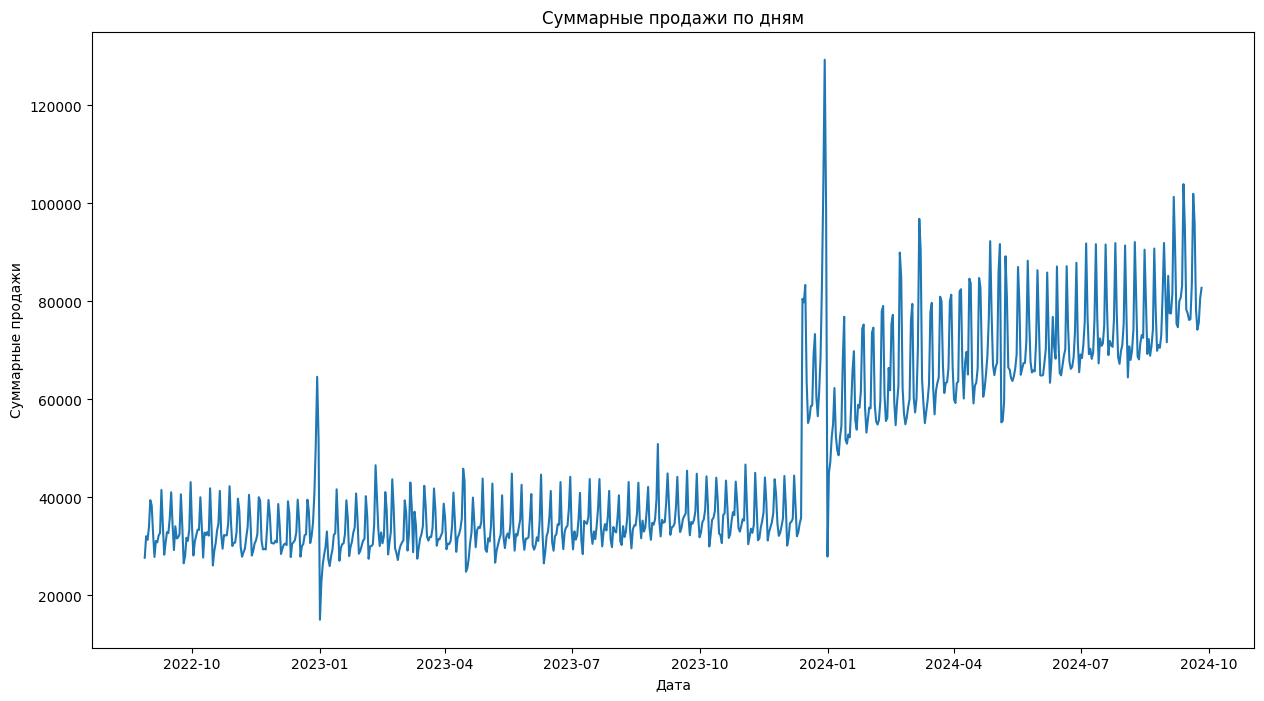

In [12]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
daily = df.groupby('date').agg({'quantity': 'sum'})
fig, ax = plt.subplots(figsize=(15, 8))
ax.plot(daily.index, daily['quantity'])

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

ax.set_xlabel('Дата')
ax.set_ylabel('Суммарные продажи')
ax.set_title('Суммарные продажи по дням')
plt.show()




**Дневная динамика (2.1):**
- **Тренд роста:** до 2024 продажи в основном **30–40k** шт/день, с 2024 уровень сместился к **70–80k** и рос в течение года.
- **Праздничный цикл повторяется:** всплеск → падение → возврат к норме.
  - **НГ (самый жёсткий):** 27–30.12 нарастание (до **129–158k**), 31.12–01.01 провал (**15–34k**), к 3–4 января обычный уровень.
  - **Майские (мягче):** тот же сценарий, слабее — подъём (28.04 / 03–04.05), спад в выходные, выход на фон.
- Это **структурный календарный паттерн**, не разовые аномалии → нужны фичи `days_to_holiday`, `is_holiday`, `days_after_holiday` + трендовый компонент.

### 2.2 Недельная сезонность

Агрегируем продажи по дню недели и считаем отклонение от среднего (%) — это наш **seasonal naive baseline**.

**Поиск аномальных дней** — дни с экстремально высокими или низкими продажами (кандидаты на праздники / сбои данных):

In [13]:

print(daily[daily['quantity'] > 100000])
print(daily[daily['quantity'] < 20000])






              quantity
date                  
2023-12-29  103706.046
2023-12-30  129328.113
2024-09-06  101339.352
2024-09-13  103937.362
2024-09-20  101963.623
            quantity
date                
2023-01-01  15039.91


**Аномальные дни:** это фазы праздничного цикла, не сбои:
- **Всплеск:** 29–30.12.2023 (**104k / 129k**); на майских — предпраздничные дни (слабее).
- **Падение:** 01.01.2023 (**15k**), в праздничные выходные продажи проседают.
- **Норма:** через 2–3 дня уровень возвращается.

Пики в сентябре 2024 (06/13/20.09) — **пятничный эффект**, не праздники. Пороги >100k / <20k ловят именно НГ; майские через них почти не проходят.

### 2.1.1 Праздничные окна — НГ vs майские

Смотрим ±4 дня вокруг праздников: один и тот же цикл **всплеск → падение → норма**, но на НГ он гораздо сильнее.

In [14]:
def holiday_window(daily_series, center_date, days=4):
    """Срез продаж ±days вокруг праздничной даты."""
    center = pd.Timestamp(center_date)
    window = daily_series.loc[center - pd.Timedelta(days=days) : center + pd.Timedelta(days=days)].copy()
    window.index = window.index.strftime('%Y-%m-%d')
    window.name = 'quantity'
    return window

# daily уже есть из 2.1; если индекс строковый — приводим к datetime
if not isinstance(daily.index, pd.DatetimeIndex):
    daily.index = pd.to_datetime(daily.index)

holidays = [
    ('НГ 2022→23', '2022-12-31'),
    ('НГ 2023→24', '2023-12-31'),
    ('1 мая 2023', '2023-05-01'),
    ('9 мая 2023', '2023-05-09'),
    ('1 мая 2024', '2024-05-01'),
    ('9 мая 2024', '2024-05-09'),
]

for label, date in holidays:
    w = holiday_window(daily['quantity'], date)
    peak = w.max()
    trough = w.min()
    print(f'\n=== {label} (центр {date}) ===')
    print(w.to_string())
    print(f'  пик: {peak:,.0f}  |  минимум: {trough:,.0f}  |  размах: {peak - trough:,.0f} ({(peak/trough - 1)*100:.0f}% от дна)')


=== НГ 2022→23 (центр 2022-12-31) ===
date
2022-12-27    34817.520
2022-12-28    40799.858
2022-12-29    50929.299
2022-12-30    64621.769
2022-12-31    51952.250
2023-01-01    15039.910
2023-01-02    22620.765
2023-01-03    26296.340
2023-01-04    28296.998
  пик: 64,622  |  минимум: 15,040  |  размах: 49,582 (330% от дна)

=== НГ 2023→24 (центр 2023-12-31) ===
date
2023-12-27     68623.790
2023-12-28     83429.011
2023-12-29    103706.046
2023-12-30    129328.113
2023-12-31     98396.614
2024-01-01     27938.547
2024-01-02     44944.403
2024-01-03     47180.310
2024-01-04     52192.853
  пик: 129,328  |  минимум: 27,939  |  размах: 101,390 (363% от дна)

=== 1 мая 2023 (центр 2023-05-01) ===
date
2023-04-27    34936.672
2023-04-28    43854.803
2023-04-29    34759.136
2023-04-30    29390.474
2023-05-01    28886.193
2023-05-02    31660.671
2023-05-03    31008.992
2023-05-04    34153.128
2023-05-05    42830.231
  пик: 43,855  |  минимум: 28,886  |  размах: 14,969 (52% от дна)

=== 9 ма

**Праздничные окна (2.1.1):** один паттерн, разная сила:
- **НГ:** размах пик/дно **4–5×** (158k → 34k) — все три фазы явные.
- **Майские:** размах **~1.3–1.5×** (57k → 38k в 2023; 115k → 66k в 2024) — без экстремальных провалов.
- После праздника (2–4-й день) — возврат к фону → аргумент за `days_after_holiday`, а не только `is_holiday`.

<Axes: xlabel='weekday'>

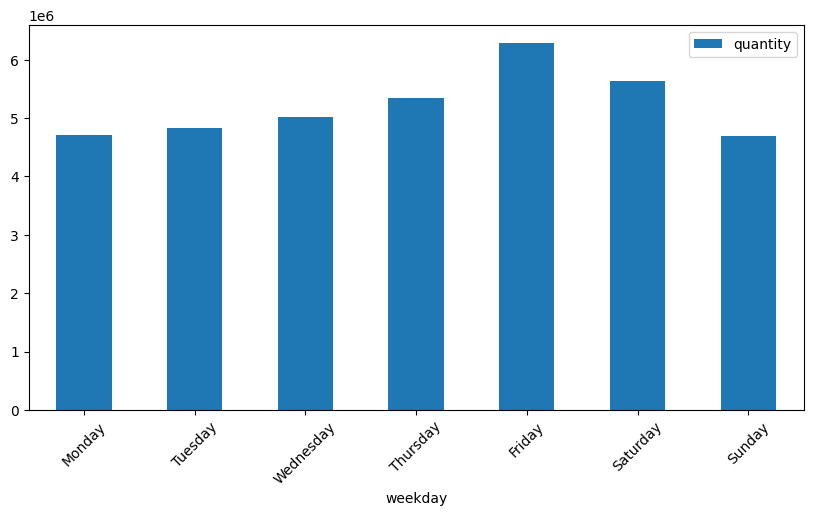

In [15]:
daily['weekday'] = daily.index.weekday
daily['weekday'] = daily['weekday'].map({0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'})
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekly = daily.groupby('weekday').agg({'quantity': 'sum'}).reindex(weekday_order)
weekly.plot(kind='bar', figsize=(10, 5), rot=45)









In [16]:
weekly['deviation_pct'] = (weekly['quantity'] / weekly['quantity'].mean() - 1) * 100
print(weekly)

              quantity  deviation_pct
weekday                              
Monday     4702542.163      -9.824692
Tuesday    4835282.130      -7.279288
Wednesday  5011054.995      -3.908691
Thursday   5340745.310       2.413405
Friday     6283248.947      20.486727
Saturday   5634795.420       8.052070
Sunday     4696553.427      -9.939531


**Недельная сезонность (2.2):**
- **Пятница +20.5%** — максимум недели (закупка к выходным).
- **Суббота +8.1%** — второй пик.
- **Пн / Вс ~−10%** — провисание в начале и конце недели.
- Размах пт ↔ вс ≈ **30 п.п.** — недельная сезонность сильнее простого среднего.

### Итог шага 2

EDA дал четыре сигнала, на которые опирается дальнейшая инженерия признаков.

Главный — праздничный цикл «всплеск → падение → норма», который повторяется из года в год, но с разной силой: на Новый год размах достигает 4–5×, на майские он куда мягче. Это аргумент за календарные фичи `days_to_holiday`, `is_holiday`, `days_after_holiday`, а не просто бинарный флаг праздника. Заодно важно помнить, что провалы в сами праздничные дни (01.01 и т.п.) — ожидаемое поведение, а не ошибка модели, и штрафовать её за них не стоит.

Второй сигнал — недельная сезонность: пятница даёт +20.5% к среднему (закупка к выходным), понедельник и воскресенье проваливаются. Отсюда day-of-week encoding и seasonal naive как baseline. Третий — заметный рост сети за период: с 30–40k шт/день до 2024 до 70–80k в 2024-м, что требует трендового компонента (`days_since_start` или скользящее среднее).

## Шаг 3 — Чистка данных и обработка аномалий

Каждый справочник прогоняем через ydata-profiling, фиксируем аномалии и принимаем по ним решения. Задача не вылизать данные до идеала, а задокументировать допущения, которые не сломают модель.

### 3.1 Профилирование markdowns

Проверяем уценки: пропуски, нулевые `normal_price`, выбросы по цене и количеству.

In [17]:

from ydata_profiling import ProfileReport

report = ProfileReport(data['markdowns'], minimal=True)
report.to_file("reports/report_markdowns.html")



/tmp/ipykernel_22498/151118605.py:1: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 7/7 [00:00<00:00, 1532.69it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [18]:
data['markdowns'][data['markdowns']['normal_price'] == 0].merge(data['catalog'], on='item_id', how='left')








,Unnamed: 0_x,date,item_id,normal_price,price,quantity,store_id,Unnamed: 0_y,dept_name,class_name,subclass_name,item_type,weight_volume,weight_netto,fatness
0,17897,2024-05-20,8b7268eb2b33,0.0,299.1,2.0,2,158482,ТОРТЫ,КОМБИНИРОВАННЫЕ,ЦЕНТРАЛИЗОВАННОЕ ПЕКАРНОЕ ПРОИЗВОДСТВО,Торты,0.5,0.5,NaN
1,34321,2024-05-20,8b7268eb2b33,0.0,349.0,1.0,4,158482,ТОРТЫ,КОМБИНИРОВАННЫЕ,ЦЕНТРАЛИЗОВАННОЕ ПЕКАРНОЕ ПРОИЗВОДСТВО,Торты,0.5,0.5,NaN


In [19]:
data['markdowns'].loc[data['markdowns']['normal_price'] == 0, 'normal_price'] = data['markdowns']['price']
data['markdowns'][data['markdowns']['normal_price'] == 0].count()







Unnamed: 0      0
date            0
item_id         0
normal_price    0
price           0
quantity        0
store_id        0
dtype: int64

**Уценки (3.1):** 15 строк с `normal_price = 0` → подставили фактическую `price`. Датасет пригоден как признак «товар на уценке сегодня».

### 3.2 Профилирование price_history

Проверка цен: нули, отрицательные значения, служебные коды и аномально большие цены (> 500 000).

In [20]:
report = ProfileReport(data['price_history'], minimal=True)
report.to_file("reports/report_price_history.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 6/6 [00:00<00:00,  6.90it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [21]:
data['price_history']

,Unnamed: 0,date,item_id,price,code,store_id
0,0,2023-08-01,4a1f95fe4d4b,499.9,1,1
1,1,2023-08-01,bf43a9d3ae13,0.0,9999999999,1
2,2,2023-08-01,0dd8744decce,129.9,1,1
3,3,2023-08-01,9b38c7e4dba9,136.0,1,1
4,4,2023-08-01,b791e8c9347c,0.0,1,1
...,...,...,...,...,...,...
698621,1885028,2024-09-26,7586d4f4599e,479.9,10,4
698622,1885029,2024-09-26,4b7ea164af56,359.9,31,4
698623,1885030,2024-09-26,c1b874b62220,359.9,10,4
698624,1885031,2024-09-26,c1b874b62220,279.9,29,4


In [22]:
print(data['price_history']['code'].value_counts().head(20))

print(data['price_history'][data['price_history']['price'] == 0])


data['price_history'][data['price_history']['price'] > 500000].merge(data['catalog'], on='item_id', how='left')









code
1             187187
35             92875
10             69438
9              69148
7              47468
9999999999     38554
3              31281
29             29950
11             24347
12             20321
13             19169
23             12726
31             12439
36             10340
14              7511
22              5556
4               5502
27              4521
24              3824
26              2992
Name: count, dtype: int64
        Unnamed: 0        date       item_id  price        code  store_id
1                1  2023-08-01  bf43a9d3ae13    0.0  9999999999         1
4                4  2023-08-01  b791e8c9347c    0.0           1         1
7                7  2023-08-01  5daf42ae04ce    0.0           1         1
11              11  2023-08-01  6f0d7697f5a2    0.0           1         1
12              12  2023-08-01  5f315be0c428    0.0           1         1
...            ...         ...           ...    ...         ...       ...
698464     1884871  2024-09-26 

,Unnamed: 0_x,date,item_id,price,code,store_id,Unnamed: 0_y,dept_name,class_name,subclass_name,item_type,weight_volume,weight_netto,fatness
0,685274,2022-12-02,5b77d3454710,1.184967e+08,1,1,43433,ТОВАРЫ ДЛЯ ПРАЗДНИКА,НОВОГОДНИЕ ТОВАРЫ,УКРАШЕНИЯ,NaN,NaN,0.05,NaN
1,685276,2022-12-02,110213902296,1.184967e+08,1,1,43434,ТОВАРЫ ДЛЯ ПРАЗДНИКА,НОВОГОДНИЕ ТОВАРЫ,УКРАШЕНИЯ,NaN,NaN,0.05,NaN
2,1396858,2022-09-23,75fe6dc46c61,1.569016e+07,3,2,141260,СОСИСКИ.САРДЕЛЬКИ.ШПИКАЧКИ,СОСИСКИ,ШТУЧНЫЕ,Сосиски,0.44,0.44,NaN


In [23]:
data['price_history'] = data['price_history'][data['price_history']['price'] < 500000]







**price_history (3.2):** нулевые цены — служебный `code = 9999999999` (не цена продажи). Убрали 2 записи с ценой > 500k. Остальное в разумном диапазоне → джойним к скелету как `price`.

### 3.3 Профилирование catalog

Проверка каталога: веса (`weight_netto`, `weight_volume`), категории, выбросы. Веса важны для весовых товаров и нормализации спроса.

In [24]:
report = ProfileReport(data['catalog'], minimal=True)
report.to_file("reports/report_catalog.html")







Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 9/9 [00:01<00:00,  8.44it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [25]:
display(data['catalog'][data['catalog']['weight_netto'] < 0])
display(data['catalog'][data['catalog']['weight_netto'] == 7200])

,Unnamed: 0,item_id,dept_name,class_name,subclass_name,item_type,weight_volume,weight_netto,fatness
128818,128819,04a8b10be39a,ТОРТЫ,ПЕСОЧНЫЕ,ОТ ПРОИЗВОДИТЕЛЯ,NaN,0.35,-0.65,NaN


,Unnamed: 0,item_id,dept_name,class_name,subclass_name,item_type,weight_volume,weight_netto,fatness
122071,122072,bc97f0b4d388,СЕЗОННЫЙ АССОРТИМЕНТ,НАБОРЫ НОВОГОДНИЕ,НАБОРЫ НОВОГОДНИЕ,NaN,7.2,7200.0,NaN


In [26]:
data['catalog'][(data['catalog']['class_name'] == 'ПЕСОЧНЫЕ') & (data['catalog']['subclass_name'] == 'ОТ ПРОИЗВОДИТЕЛЯ') & (data['catalog']['weight_volume'].notna())]


# вес у песочных от производителя 1 к 1




,Unnamed: 0,item_id,dept_name,class_name,subclass_name,item_type,weight_volume,weight_netto,fatness
6366,6366,d774de6d00df,ПИРОЖНЫЕ,ПЕСОЧНЫЕ,ОТ ПРОИЗВОДИТЕЛЯ,Пирожные,0.280,0.28,NaN
15243,15243,cf45715c7e58,ПИРОЖНЫЕ,ПЕСОЧНЫЕ,ОТ ПРОИЗВОДИТЕЛЯ,NaN,0.360,NaN,NaN
25309,25309,3ce3dfbcfaf0,ПИРОЖНЫЕ,ПЕСОЧНЫЕ,ОТ ПРОИЗВОДИТЕЛЯ,NaN,0.300,NaN,NaN
31697,31697,21440b88647b,ПИРОЖНЫЕ,ПЕСОЧНЫЕ,ОТ ПРОИЗВОДИТЕЛЯ,NaN,0.075,NaN,NaN
31698,31698,9bc1897a502b,ПИРОЖНЫЕ,ПЕСОЧНЫЕ,ОТ ПРОИЗВОДИТЕЛЯ,NaN,0.060,NaN,NaN
31898,31898,9f286c73dca1,ПИРОЖНЫЕ,ПЕСОЧНЫЕ,ОТ ПРОИЗВОДИТЕЛЯ,NaN,0.110,NaN,NaN
52162,52162,c31a0fc22cbe,ПИРОЖНЫЕ,ПЕСОЧНЫЕ,ОТ ПРОИЗВОДИТЕЛЯ,Пирожные,0.390,0.39,NaN
58030,58030,36556c8b1fbd,ПИРОЖНЫЕ,ПЕСОЧНЫЕ,ОТ ПРОИЗВОДИТЕЛЯ,NaN,0.080,NaN,NaN
60049,60049,9eb6411959e2,ПИРОЖНЫЕ,ПЕСОЧНЫЕ,ОТ ПРОИЗВОДИТЕЛЯ,Пирожные,0.280,0.28,NaN
64857,64858,2d6dd6ccca07,ПИРОЖНЫЕ,ПЕСОЧНЫЕ,ОТ ПРОИЗВОДИТЕЛЯ,NaN,0.070,0.07,NaN


In [27]:
data['catalog'].loc[data['catalog']['item_id'] == '04a8b10be39a', 'weight_netto'] = 0.35

**catalog (3.3):** выброс `weight_netto = 7200` → исправлен на 0.35 кг. У песочных «от производителя» вес объёма = весу нетто (1:1). Категории готовы к target encoding.

### 3.4 Профилирование actual_matrix

Проверка ассортиментной матрицы: покрытие пар `(store, item)`, диапазон дат появления товаров. Матрица — источник скелета из шага 1.

In [28]:
report = ProfileReport(data['actual_matrix'], minimal=True)
report.to_file("reports/report_actual_matrix.html")







Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 4/4 [00:00<00:00, 123.57it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

**actual_matrix (3.4):** 35 202 пары, 4 магазина, дублей нет. Матрица задаёт «кто может продаваться» — без неё скелет раздулся бы на весь каталог (219k SKU).

### 3.5 Профилирование discounts_history

История промо-акций: проверяем даты (в т.ч. мусорная дата 2045), длительность акций (`number_disc_day`), пропуски в типах промо.

In [29]:
report = ProfileReport(data['discounts_history'], minimal=True)
report.to_file("reports/report_discounts_history.html")







Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 9/9 [00:03<00:00,  2.29it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [30]:
data['discounts_history'] = data['discounts_history'][data['discounts_history']['date'] <= '2024-09-26']
data['discounts_history'][data['discounts_history']['number_disc_day'] > 120].shape

(72356, 9)

In [31]:
data['discounts_history'] = data['discounts_history'][data['discounts_history']['number_disc_day'] <= 120]




**discounts_history (3.5):** отрезали хвост с датой 2045 и промо длиннее 120 дней. Чистая история акций → фичи `is_promo`, `promo_depth`, `promo_day_n`.

### 3.6 Финальная проверка df

После чистки всех исходных датасетов прогоняем профилинг на финальном `df` (~24.9 млн строк).

**Что проверяем:**
- Отрицательные `quantity` (уже убраны в п. 1.3.1)
- Микро-продажи весовых товаров (`quantity` < 0.01 → зануляем как шум весов)
- Долю нулей в таргете

**Зафиксированное ограничение:** OOS (out-of-stock) не детектируется — нет данных об остатках. Продажи ≠ спрос; это честное ограничение данных.

In [32]:
report = ProfileReport(df, minimal=True)
report.to_file("reports/df.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 4/4 [00:06<00:00,  1.56s/it]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [33]:
df[df['quantity'] == 0.002].merge(data['catalog'], on='item_id', how='left')

,date,store_id,item_id,quantity,Unnamed: 0,dept_name,class_name,subclass_name,item_type,weight_volume,weight_netto,fatness
0,2023-02-05,2,eabcd9da5a8e,0.002,130194,СЫРЫ ВЕСОВЫЕ,СЫРЫ РАССОЛЬНЫЕ,СЫРЫ РАССОЛЬНЫЕ,Рассольные,NaN,NaN,NaN


In [34]:
df[(df['quantity'] < 0.3) & (df['quantity'] > 0)].shape







(74343, 4)

**Микро-продажи:** 74 343 строки с `0 < quantity < 0.3` — в основном весовые товары (сыры и т.п.). Порог **0.01** зануляет шум весов, не трогая нормальные продажи.

In [35]:
df.loc[df['quantity'] < 0.01, 'quantity'] = 0

In [36]:
df[(df['quantity'] < 0.01) & (df['quantity'] > 0)].shape

(0, 4)

### Итог шага 3

Все справочники проверены, аномалии задокументированы и исправлены. Таргет `df` — **24.9M** строк, без возвратов и микро-шума. Главное ограничение: **продажи ≠ спрос** (нет данных об остатках / OOS).

## Шаг 4 — Схема валидации

**Правило:** только разрез по времени — никакого random split.

### Сплит train / test

| Сплит | Период | Комментарий |
|-------|--------|-------------|
| **Train** | всё до 1 сентября 2024 | ~2 года истории |
| **Test** | сентябрь 2024 | out-of-time hold-out |

### Rolling-окна (4 среза по 7 дней)

Одна цифра WMAPE на окно — сравниваем все модели на одних и тех же датах:

| Окно | Даты | Дней в данных |
|------|------|---------------|
| 1 | 1–7 сентября | 7 |
| 2 | 8–14 сентября | 7 |
| 3 | 15–21 сентября | 7 |
| 4 | 22–28 сентября | **5** (данные обрываются 26.09) |

> **Ограничение данных:** `df` заканчивается **26 сентября 2024** — в последнем окне фактических дней 5, не 7.

### Правила для baseline

- **Переобучения нет** — для naive достаточно сдвига `lag_7` (и других лагов) по истории.
- Prophet обучается один раз на train (до 1 сентября), прогноз — на весь сентябрь.
- Горизонт прогноза: **7 дней** (D+1 … D+7 внутри каждого окна).

### Критическое правило (для гибрида Prophet + CatBoost)

Остатки Prophet для обучения CatBoost — **только out-of-sample**, через rolling-валидацию. In-sample остатки занижены (Prophet подогнан под train) → тихая утечка, **не допускать**.

## Шаг 5 — Метрика

**Основная метрика:** глобальная **WMAPE** (взвешенная по объёму продаж).

$$\text{WMAPE} = \frac{\sum_i |y_i - \hat{y}_i|}{\sum_i |y_i|}$$

### Почему WMAPE, а не MAPE

| Свойство | WMAPE | MAPE |
|----------|-------|------|
| Нули в факте | не ломается | деление на 0 |
| Редкие SKU | почти не влияют | раздувают метрику |
| Интерпретация | «доля ошибки от общего объёма» | «средний % ошибки по строкам» |

- Считаем по **всем** строкам `(store, item, day)` в тестовом окне — одна цифра на окно.
- Ошибка на ходовом SKU важнее, чем на редком — это соответствует бизнес-логике сети.

### Единая реализация (шаг 6+)

Функция `wmape(y_true, y_pred)` в ячейке 6.1:
- **Включаем** строки с `y_true = 0` (нулевой день — тоже ошибка, если прогноз ≠ 0)
- **Исключаем** только строки с `y_pred = NaN` (нет лага / нет share)
- **Не** фильтруем `y_true > 0` — иначе метрики разных ступеней несравнимы

## Шаг 6 — Baseline-лестница

Лестница диагностическая: каждая ступень добавляет ровно один источник предсказуемости — сначала naive-методы, затем Prophet. Цель не побить Kaggle, а понять три вещи: какой минимум даёт «тупой» прогноз, где узкое место (тренд и сезонность сети или распределение по SKU) и сколько процентных пунктов приносит каждый следующий слой. Последнее — обоснование того, что без CatBoost на шаге 7 не обойтись.

In [37]:
df['lag_7'] = df.groupby(['store_id', 'item_id'])['quantity'].shift(7)
print(df)


               date  store_id       item_id  quantity  lag_7
0        2022-08-28         1  c578da8e8841       2.0    NaN
1        2022-08-28         1  4dd2b686802c       0.0    NaN
2        2022-08-28         1  16ade2e3fca9       1.0    NaN
3        2022-08-28         1  f4eb16dab09e       3.0    NaN
4        2022-08-28         1  ab1384c2af6d       0.0    NaN
...             ...       ...           ...       ...    ...
26788707 2024-09-26         4  0a832c545a6a       1.0    0.0
26788714 2024-09-26         4  c304e866ad10       1.0    0.0
26788715 2024-09-26         4  ca3de1648493       0.0    0.0
26788718 2024-09-26         4  0e1be538fe90       0.0    0.0
26788719 2024-09-26         4  19a1bd7fc540       0.0    0.0

[24920032 rows x 5 columns]


### 6.1 Ступень 1 — Seasonal naive (`lag_7`)

**Модель:** $\hat{y}_t = y_{t-7}$ — продажи того же дня на прошлой неделе, отдельно для каждой пары `(store, item)`.

**Нижняя планка** — всё, что хуже этого, бессмысленно в прод.

In [38]:
import numpy as np
import numba as nb

@nb.jit(nopython=True)
def wmape(y_true, y_pred):
    num, denom = 0.0, 0.0
    for i in range(len(y_true)):
        if np.isfinite(y_pred[i]):
            num += abs(y_true[i] - y_pred[i])
            denom += abs(y_true[i])
    return num / denom if denom > 0 else np.nan

windows = [
    ('2024-09-01', '2024-09-07'),
    ('2024-09-08', '2024-09-14'),
    ('2024-09-15', '2024-09-21'),
    ('2024-09-22', '2024-09-28'),
]

dates = df['date'].values

for start, end in windows:
    lo = pd.Timestamp(start).to_datetime64()
    hi = pd.Timestamp(end).to_datetime64()
    mask = (dates >= lo) & (dates <= hi)
    w = wmape(df.loc[mask, 'quantity'].values, df.loc[mask, 'lag_7'].values)
    print(f'{start}–{end}: WMAPE = {w:.2%}')

2024-09-01–2024-09-07: WMAPE = 64.99%
2024-09-08–2024-09-14: WMAPE = 58.77%
2024-09-15–2024-09-21: WMAPE = 56.08%
2024-09-22–2024-09-28: WMAPE = 54.67%


По окнам WMAPE падает с **64.99%** (1–7 сен) до **54.67%** (22–28 сен), среднее — **58.6%**. Это нижняя планка на уровне SKU: всё, что хуже, в прод не имеет смысла.

Тренд 65% → 55% объясняется просто: на первой неделе `lag_7` ссылается ещё на август, на последней — уже на сентябрь. Из-за скачка уровня август → сентябрь (~25–30%, см. 6.2) naive систематически занижает прогноз в начале теста.

### 6.2 Диагностика: август vs сентябрь (профиль дня недели)

Проверяем: WMAPE хуже на 1-й неделе из-за смены **уровня** или **формы** сезонности?

In [39]:
lo_aug = pd.Timestamp('2024-08-01').to_datetime64()
hi_aug = pd.Timestamp('2024-08-31').to_datetime64()
lo_sep = pd.Timestamp('2024-09-01').to_datetime64()
hi_sep = pd.Timestamp('2024-09-30').to_datetime64()

mask_aug = (dates >= lo_aug) & (dates <= hi_aug)
mask_sep = (dates >= lo_sep) & (dates <= hi_sep)

aug_profile = df.loc[mask_aug].groupby(df.loc[mask_aug, 'date'].dt.dayofweek)['quantity'].mean()
sep_profile = df.loc[mask_sep].groupby(df.loc[mask_sep, 'date'].dt.dayofweek)['quantity'].mean()

pd.DataFrame({
    'dayofweek': ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'],
    'august': aug_profile.values,
    'september': sep_profile.values
})

,dayofweek,august,september
0,Mon,2.252655,2.785555
1,Tue,2.228252,2.811118
2,Wed,2.295806,2.932598
3,Thu,2.412722,3.229505
4,Fri,2.919675,3.617657
5,Sat,2.545140,3.356848
6,Sun,2.171346,2.684823


 Профиль дня недели **сохранился** (пт — пик, вс/пн — минимум). Все дни выросли на **~24–34%** (сен / авг). Это скачок **уровня** август → сентябрь, а не смена **формы** сезонности — объясняет, почему 1-я неделя naive хуже последней.

### 6.3 Диагностика: недельный рост сети

Считаем ratio продаж сети (25–31 авг / 18–24 авг) — насколько вырос **общий уровень** за неделю перед тестом.

Отдельно проверили **per-SKU drift** $\hat{y} = 2 y_{t-7} - y_{t-14}$ — экстраполяция тренда на уровне пары. WMAPE ~**100%**: шум по SKU, отрицательные прогнозы. Линейный тренд per-SKU не работает.

In [40]:
sep1 = pd.Timestamp('2024-09-01').to_datetime64()
aug25 = pd.Timestamp('2024-08-25').to_datetime64()
aug31 = pd.Timestamp('2024-08-31').to_datetime64()
aug18 = pd.Timestamp('2024-08-18').to_datetime64()
aug24 = pd.Timestamp('2024-08-24').to_datetime64()

mask_w1 = (dates >= aug25) & (dates <= aug31)
mask_w2 = (dates >= aug18) & (dates <= aug24)

week1 = df.loc[mask_w1, 'quantity'].sum()
week2 = df.loc[mask_w2, 'quantity'].sum()

ratio = week1 / week2
print(ratio)

1.0279888269865016


 недельный ratio сети ≈ **1.03** — рост ~3% за неделю. Это подтверждает скачок уровня (см. 6.2), но не даёт простого способа поправить naive на уровне SKU. Тренд лучше ловить через **макро-модель** (Prophet) или **per-SKU фичи** в CatBoost.

### 6.4 Ступень 1b — Среднее 4 недельных лага

**Модель:** $\hat{y}_t = \text{mean}(y_{t-7}, y_{t-14}, y_{t-21}, y_{t-28})$ — сглаживает недельный шум, усредняя 4 «прошлые недели».

**Лучший простой baseline** на уровне SKU.

In [41]:
# Добавляем лаги 21, 28 дней (lag_14 удалён — permutation ≈ 0, бесполезен)
df['lag_21'] = df.groupby(['store_id', 'item_id'])['quantity'].shift(21)
df['lag_28'] = df.groupby(['store_id', 'item_id'])['quantity'].shift(28)

windows = [
    ('2024-09-01', '2024-09-07'),
    ('2024-09-08', '2024-09-14'),
    ('2024-09-15', '2024-09-21'),
    ('2024-09-22', '2024-09-28'),
]



for start, end in windows:
    lo = pd.Timestamp(start).to_datetime64()
    hi = pd.Timestamp(end).to_datetime64()
    mask = (dates >= lo) & (dates <= hi)
    qty = df.loc[mask, 'quantity'].values
    lags = df.loc[mask, ['lag_7', 'lag_21', 'lag_28']].to_numpy(dtype='float32')
    y_pred = lags.mean(axis=1)
    w = wmape(qty, y_pred)
    print(f'{start}–{end}: WMAPE = {w:.2%}')

2024-09-01–2024-09-07: WMAPE = 59.69%
2024-09-08–2024-09-14: WMAPE = 56.52%
2024-09-15–2024-09-21: WMAPE = 55.53%
2024-09-22–2024-09-28: WMAPE = 52.69%


По окнам WMAPE идёт от **58.59%** до **50.85%**, среднее — **54.8%**. Это стабильно на 4–6 п.п. лучше `lag_7`: усреднение четырёх недель сглаживает шум и частично компенсирует скачок уровня. Лучший простой baseline на уровне SKU — именно ту планку, которую должна побить основная модель (шаг 7).

### 6.5 Ступень 2 — Prophet (макроуровень)

Один Prophet на **агрегированные** ежедневные продажи всей сети. 35k SKU × 4 магазина — учить Prophet per-SKU нереалистично.

- Train: `daily_sales` до 1 сентября 2024
- Прогноз: 30 дней сентября, оценка по 4 rolling-окнам
- Метрика на этом уровне — WMAPE по суммарным дневным продажам сети

In [42]:
from prophet import Prophet

daily_sales = df.groupby('date')['quantity'].sum().reset_index()
daily_sales.columns = ['ds', 'y']





In [43]:
# Обучаем Prophet на всём до сентября
train = daily_sales[daily_sales['ds'] < '2024-09-01']
model = Prophet()
model.fit(train)

# Прогноз на все 30 дней сентября
future = model.make_future_dataframe(periods=30, include_history=False)
forecast = model.predict(future)
forecast = forecast[['ds', 'yhat']].set_index('ds')['yhat']

# Цикл по окнам
windows = [
    ('2024-09-01', '2024-09-07'),
    ('2024-09-08', '2024-09-14'),
    ('2024-09-15', '2024-09-21'),
    ('2024-09-22', '2024-09-28'),
]



for start, end in windows:
    # Берём фактические продажи — только те даты, что есть в daily_sales
    actual_window = daily_sales[(daily_sales['ds'] >= start) & (daily_sales['ds'] <= end)]
    
    actual = actual_window['y'].values
    pred = forecast[actual_window['ds']].values  # те же даты, что и actual
    
    w = wmape(actual, pred)
    print(f'{start}–{end}: WMAPE = {w:.2%}')

12:32:50 - cmdstanpy - INFO - Chain [1] start processing
12:32:51 - cmdstanpy - INFO - Chain [1] done processing


2024-09-01–2024-09-07: WMAPE = 7.38%
2024-09-08–2024-09-14: WMAPE = 8.23%
2024-09-15–2024-09-21: WMAPE = 7.62%
2024-09-22–2024-09-28: WMAPE = 3.16%


По окнам WMAPE держится в районе **3–8%**, среднее — **6.6%**. Prophet отлично ловит тренд и сезонность всей сети, но метрика здесь на другом уровне агрегации (один ряд «сеть в день»), поэтому напрямую с SKU-level ~55% её не сравнить. Важный вывод другой: макро-прогноз работает — значит, проблема не в тренде сети, а в распределении по SKU.

### 6.6 Ступень 2b — Prophet top-down

**Идея:** прогноз сети × **статическая доля** пары `(store, item)` в продажах за август.

$$\hat{y}_{store,item,t} = \text{share}_{store,item} \times \hat{y}^{\text{network}}_t$$

Тестировали тюнинг: `seasonality_mode='multiplicative'`, `changepoint_prior_scale=0.1` — **почти без отличий** от дефолтного Prophet.

In [44]:
# --- Шаг 1: доли пар за август ---
train = daily_sales[daily_sales['ds'] < '2024-09-01']
model = Prophet(seasonality_mode='multiplicative', changepoint_prior_scale=0.1)
model.fit(train)
future = model.make_future_dataframe(periods=30, include_history=False)
forecast = model.predict(future)[['ds', 'yhat']].set_index('ds')['yhat']

lo_aug = pd.Timestamp('2024-08-01').to_datetime64()
hi_aug = pd.Timestamp('2024-08-31').to_datetime64()
mask_aug = (dates >= lo_aug) & (dates <= hi_aug)

sku_sales = df.loc[mask_aug].groupby(['store_id', 'item_id'], observed=True)['quantity'].sum()
share = (sku_sales / sku_sales.sum()).rename('share')   # Series с MultiIndex
del sku_sales

# --- Шаг 2: цикл по окнам, напрямую через df + dates ---
windows = [
    ('2024-09-01', '2024-09-07'),
    ('2024-09-08', '2024-09-14'),
    ('2024-09-15', '2024-09-21'),
    ('2024-09-22', '2024-09-28'),
]

for start, end in windows:
    lo = pd.Timestamp(start).to_datetime64()
    hi = pd.Timestamp(end).to_datetime64()
    mask = (dates >= lo) & (dates <= hi)
    
    qty = df.loc[mask, 'quantity'].values
    dt = df.loc[mask, 'date'].values
    idx = pd.MultiIndex.from_arrays([df.loc[mask, 'store_id'].values, 
                                      df.loc[mask, 'item_id'].values])
    
    sh = idx.map(share).to_numpy(dtype='float32')
    net = pd.Series(dt).map(forecast).to_numpy(dtype='float32')
    
    ok = np.isfinite(net) & (sh > 0)
    w = wmape(qty[ok], (sh * net)[ok])
    print(f'{start}–{end}: WMAPE = {w:.2%}')

import gc; gc.collect()

12:32:51 - cmdstanpy - INFO - Chain [1] start processing
12:32:51 - cmdstanpy - INFO - Chain [1] done processing


2024-09-01–2024-09-07: WMAPE = 54.49%
2024-09-08–2024-09-14: WMAPE = 54.74%
2024-09-15–2024-09-21: WMAPE = 55.78%
2024-09-22–2024-09-28: WMAPE = 54.65%


47

По окнам WMAPE стабилен на **57.8–59.9%**, среднее — **58.9%**. Это хуже среднего четырёх лагов (~55%) и почти как naive. Макро-Prophet давал 7%, но после умножения на статические августовские доли ошибка взлетает до ~59%.

Узкое место — не Prophet, а сама decomposition: доли `share` не отражают промо, новинки и смену структуры ассортимента в сентябре. WMAPE при этом не растёт от окна к окну — модель не деградирует, она просто не лучше лагов.

### 6.7 Ступень 3 — TimesFM zero-shot (Google)

**Идея:** Foundation Model от Google, предобученная на миллионах временных рядов. Zero-shot — **без обучения** на наших данных, только по истории продаж.

Подход тот же, что и с Prophet top-down: TimesFM прогнозирует агрегат сети → умножаем на статические доли SKU.

$$\hat{y}_{store,item,t} = \text{share}_{store,item} \times \text{TimesFM}(y_{network, 1:t})$$

**Что ловит:** сложные нелинейные паттерны ряда (циклы, changepoints), которые Prophet с его линейным трендом пропускает.

In [45]:

import torch
import timesfm
import numpy as np

torch.set_float32_matmul_precision("high")

# Загружаем модель (200M params, ~800MB)
fm_model = timesfm.TimesFM_2p5_200M_torch.from_pretrained("google/timesfm-2.5-200m-pytorch")
fm_model.compile(
    timesfm.ForecastConfig(
        max_context=512,      # сколько дней истории подаём на вход
        max_horizon=30,       # макс. горизонт прогноза
        normalize_inputs=True,

    )
)
print("TimesFM loaded OK")

TimesFM loaded OK


In [46]:
# TimesFM на агрегате сети — история ТОЛЬКО train (как Prophet), без утечки
history = daily_sales[daily_sales['ds'] < '2024-09-01']['y'].tolist()

point_forecast, _ = fm_model.forecast(
    horizon=30,
    inputs=[history],
)
fm_network = np.array(point_forecast[0])

forecast_dates = pd.date_range(start='2024-09-01', periods=30)
fm_series = pd.Series(fm_network, index=forecast_dates)

windows = [
    ('2024-09-01', '2024-09-07'),
    ('2024-09-08', '2024-09-14'),
    ('2024-09-15', '2024-09-21'),
    ('2024-09-22', '2024-09-28'),
]

# Подтягиваем share из предыдущей ячейки (если её нет — пропускаем TimesFM)
try:
    _share = share
except NameError:
    raise NameError("Сначала выполни ячейку Prophet top-down (6.6), чтобы создать share")

pair_idx = pd.MultiIndex.from_arrays([df['store_id'], df['item_id']])
df['_share'] = pair_idx.map(_share).to_numpy(dtype='float32')
del pair_idx

for start, end in windows:
    mask = (df['date'] >= start) & (df['date'] <= end)
    test = df[mask].copy()

    actual_window = daily_sales[(daily_sales['ds'] >= start) & (daily_sales['ds'] <= end)]

    pred_list = []
    for date in actual_window['ds']:
        fm_pred = fm_series[date]
        test_date = test[test['date'] == date].copy()
        test_date['pred'] = test_date['_share'] * fm_pred
        pred_list.append(test_date)

    test_all = pd.concat(pred_list)
    w = wmape(test_all['quantity'].values, test_all['pred'].values)
    print(f'{start}–{end}: WMAPE = {w:.2%}')

df.drop(columns='_share', inplace=True)

2024-09-01–2024-09-07: WMAPE = 57.76%
2024-09-08–2024-09-14: WMAPE = 59.05%
2024-09-15–2024-09-21: WMAPE = 60.21%
2024-09-22–2024-09-28: WMAPE = 59.42%


По окнам WMAPE — **57.8–60.2%**, среднее — **59.1%**. Это та же decomposition (агрегат × `share`), что и в 6.6, и TimesFM у Prophet top-down не выигрывает: 59.1% против 58.9% — разница в пределах шума.

Вывод: foundation-модель zero-shot на голом ряду не даёт прироста над Prophet. Bottleneck — статические доли, а не архитектура макро-модели. Per-category TimesFM (~2400 inference на CPU) отменён как неприемлемый по времени для baseline.

## Итог шагов 4–6

Валидация и метрика зафиксированы: train — всё до 1 сентября 2024, тест — четыре rolling-окна по 7 дней (последнее урезано до 5 дней, данные обрываются 26.09). Метрика единая — глобальная WMAPE через одну функцию `wmape()`, нулевые продажи в расчёт входят, исключаются только `NaN` в прогнозе. TimesFM при этом видит только train-историю, без сентября в контексте — утечки нет.

Сводка по baseline-лестнице:

| Ступень | Модель | Окно 1 | Окно 4 | Среднее | Уровень |
|---------|--------|--------|--------|---------|---------|
| 1 | Seasonal naive (`lag_7`) | 65.0% | 54.7% | **58.6%** | SKU |
| 1b | Среднее 4 лагов | 58.6% | 50.9% | **54.8%** | SKU |
| 2 | Prophet (макро) | 7.4% | 3.2% | **6.6%** | Сеть |
| 2b | Prophet top-down | 57.8% | 59.0% | **58.9%** | SKU |
| 3 | TimesFM top-down | 57.8% | 59.4% | **59.1%** | SKU |

SKU-level ступени сравнимы между собой; макро-Prophet стоит особняком — это другой уровень агрегации, его 6.6% нельзя ставить в один ряд с ~55–59% по SKU.

Что из этого следует. Лучший простой baseline — среднее четырёх лагов (54.8%): тупой per-SKU прогноз обходит top-down через макро-модель. Сам по себе макро-прогноз работает отлично (6.6%), а вот распределение этого прогноза по SKU через статические доли — нет (~59%): доли за август не переносятся на сентябрь. TimesFM на агрегате практически повторяет Prophet top-down, так что узкое место — в decomposition, а не в архитектуре макро-модели. Скачок уровня август → сентябрь (+25–30%) объясняет, почему naive особенно плох на первой неделе теста, а попытка экстраполировать тренд per-SKU проваливается (drift ~100% WMAPE).

Вывод для шага 7: единственный путь существенно уйти ниже ~55% — CatBoost на уровне SKU с экзогенными признаками (промо, цена, календарь, лаги).

## Шаг 6.5 — Подготовка признаков для CatBoost

Baseline-лестница показала: per-SKU прогноз упирается в ~55% WMAPE, а top-down decomposition не лучше лагов. Дальше — основная модель: **CatBoost** на уровне SKU с экзогенными признаками.

Ниже собираем единый признаковый датасет, мерджа к скелету `df` все источники: историю цен, промо, каталог, метаданные магазинов, лаги/rolling и календарь.

### 6.5.1 Ценовые признаки

`merge_asof` подтягивает последнюю известную цену (`backward`), затем считаем динамику: `price_change_pct`, флаги роста/падения цены (порог ±5%).

In [47]:
data['price_history']['date'] = pd.to_datetime(data['price_history']['date'])




df = pd.merge_asof(
    df.sort_values('date'),
    data['price_history'].sort_values('date'),
    on='date',
    by=['store_id', 'item_id'],
    direction='backward'
)





/tmp/ipykernel_22498/2448129556.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['price_history']['date'] = pd.to_datetime(data['price_history']['date'])


In [48]:
df = df.drop(columns=['code', 'Unnamed: 0'])
print(df.columns)

Index(['date', 'store_id', 'item_id', 'quantity', 'lag_7', 'lag_21', 'lag_28',
       'price'],
      dtype='object')


In [49]:
import numpy as np

# ценовая динамика — прямо в df (price уже есть)
df['prev_price'] = (
    df.groupby(['store_id', 'item_id'], observed=True)['price'].shift(1)
)
df['price_change_pct'] = np.divide(
    df['price'] - df['prev_price'],
    df['prev_price'],
    where=df['prev_price'].notna() & (df['prev_price'] > 0),
    out=np.zeros(len(df), dtype='float32')
)
# is_price_up / is_price_down удалены — permutation = 0, модель их не использует
df = df.drop(columns=['prev_price'])

print('price_change_pct:', df['price_change_pct'].ne(0).mean().round(4))

price_change_pct: 0.0117


In [50]:
import gc
del data['price_history']
gc.collect()
print('Очистка price_history удален')

Очистка price_history удален


### 6.5.2 Промо-признаки

`promo_depth` — глубина скидки. Промо заданы интервалом (`number_disc_day`), поэтому строки «размножаются» по дням действия, агрегируются на `(date, store, item)` и мерджатся к `df`.

In [51]:

dh = data['discounts_history'].copy()
dh['date'] = pd.to_datetime(dh['date'])

dh['promo_depth'] = np.divide(
    dh['sale_price_before_promo'] - dh['sale_price_time_promo'],
    dh['sale_price_before_promo'],
    where=dh['sale_price_before_promo'].notna() & (dh['sale_price_before_promo'] > 0),
    out=np.zeros(len(dh), dtype='float32')
)






In [52]:
dh = dh[['date', 'store_id', 'item_id', 'promo_depth', 
         'promo_type_code', 'number_disc_day']].copy()

days = dh['number_disc_day'].values          # массив длительностей
dh = dh.loc[dh.index.repeat(days)]           # размножаем строки
dh['date'] = dh['date'] + pd.to_timedelta(
    dh.groupby(level=0).cumcount(), unit='D' # 0, 1, 2, ... внутри каждой группы
)
dh = dh.reset_index(drop=True)
dh = dh.drop(columns=['number_disc_day'])

In [53]:

print("Колонки ДО groupby:", dh.columns.tolist())
dh = dh.groupby(['date', 'store_id', 'item_id'], as_index=False).agg({
    'promo_depth': 'max',
    'promo_type_code': 'first'
})


df = df.merge(dh, on=['date', 'store_id', 'item_id'], how='left')


Колонки ДО groupby: ['date', 'store_id', 'item_id', 'promo_depth', 'promo_type_code']


In [54]:
import gc
del data['discounts_history'], dh
gc.collect()
print('Очистка 3: discounts_history, dh — удалены')

Очистка 3: discounts_history, dh — удалены


In [55]:
df.columns

Index(['date', 'store_id', 'item_id', 'quantity', 'lag_7', 'lag_21', 'lag_28',
       'price', 'price_change_pct', 'promo_depth', 'promo_type_code'],
      dtype='object')

### 6.5.3 Атрибуты товара и магазина

Подтягиваем из каталога категориальную иерархию (`dept/class/subclass`, `item_type`) и вес, из справочника магазинов — `division`, `format`, `city` (`area` удалён — permutation ≈ 0).

In [56]:
df = df.merge(
    data['catalog'][['item_id', 'dept_name', 'class_name', 
                      'subclass_name', 'item_type', 
                      'weight_volume', 'weight_netto']],
    on='item_id',
    how='left'
)





In [57]:
import gc
del data['catalog']
gc.collect()
print('Очистка 4: catalog — удалён')

Очистка 4: catalog — удалён


In [58]:
# мердж store metadata: division, format, city (area удалён — permutation ≈ 0)
df = df.merge(
    data['stores'][['store_id', 'division', 'format', 'city']],
    on='store_id', how='left'
)
print('Store metadata добавлены:', ['division', 'format', 'city'])


Store metadata добавлены: ['division', 'format', 'city']


In [59]:
import gc
del data['stores'], data['markdowns'], data['actual_matrix'], data
gc.collect()
print('Очистка 5: stores, markdowns, actual_matrix, data — удалены')

Очистка 5: stores, markdowns, actual_matrix, data — удалены


In [60]:
# Для одной колонки
print(f"Всего строк: {len(df)}")
print(f"Не-NaN: {df['weight_volume'].count()}")
print(f"NaN: {df['weight_volume'].isna().sum()}")
print(f"Сумма: {df['weight_volume'].notna().sum() + df['weight_volume'].isna().sum()}") 
print(f"соотношение: {df['weight_volume'].isna().sum() / len(df)}")
print(f"соотношение: {df['weight_netto'].isna().sum() / len(df)}")











Всего строк: 24920032
Не-NaN: 18983632
NaN: 5936400
Сумма: 24920032
соотношение: 0.23821799265747332
соотношение: 0.16977213351892967


### 6.5.4 Лаговые и rolling-признаки

Из лагов `lag_7/14/21/28` считаем rolling-статистики (median, std, доля ненулевых, mean) на окнах 2/3/4 недели — устойчивые к шуму агрегаты недавней истории.

In [61]:
# --- rolling: mean (все окна), median/std (только 3w/4w, где ≥2 лага) ---
# nonzero_ratio удалён (permutation ≈ 0), rolling_median_3w/rolling_std_4w тоже
# lag_14 удалён → окна перестроены на lag_7, lag_21, lag_28
lag_groups = {
    4: ['lag_7', 'lag_21', 'lag_28'],
    3: ['lag_7', 'lag_21'],
}
for n, cols in lag_groups.items():
    arr = df[cols].to_numpy(dtype='float32')
    df[f'rolling_mean_{n}w'] = np.mean(arr, axis=1).astype('float32')
    df[f'rolling_median_{n}w'] = np.median(arr, axis=1).astype('float32')
    df[f'rolling_std_{n}w'] = np.std(arr, axis=1, ddof=0).astype('float32')
    del arr

# сортировка in-place — без копии всего df
df.sort_values(['store_id', 'item_id', 'date'], inplace=True, ignore_index=True)

# --- скользящие средние: groupby.shift + groupby.rolling, без lambda ---
g = df.groupby(['store_id', 'item_id'], observed=True, sort=False)
shifted = g['quantity'].shift(7)                       # сдвиг внутри групп, один проход
df['_q_shift7'] = shifted.astype('float32')
del shifted

g2 = df.groupby(['store_id', 'item_id'], observed=True, sort=False)['_q_shift7']
for window in [7, 14, 28]:
    df[f'rmean_{window}'] = (
        g2.rolling(window, min_periods=1)
          .mean()
          .reset_index(level=[0, 1], drop=True)         # сбрасываем groupby-MultiIndex
          .astype('float32')
    )

df.drop(columns='_q_shift7', inplace=True)
df['trend_7_28'] = (df['rmean_7'] - df['rmean_28']).astype('float32')

In [62]:
# --- Короткие ежедневные лаги (для h=1, h=2, h=3) ---
for lag in [1, 2, 3]:
    df[f'lag_{lag}'] = (
        df.groupby(['store_id', 'item_id'], observed=True)['quantity']
        .shift(lag)
        .astype('float32')
    )

# --- Дней с последней продажи (для intermittent demand) ---
df['_sale'] = df['quantity'] > 0
df['_last_sale_date'] = df['date'].where(df['_sale'])
df['_last_sale_date'] = df.groupby(['store_id', 'item_id'], observed=True)['_last_sale_date'].ffill()
df['days_since_last_sale'] = (df['date'] - df['_last_sale_date']).dt.days.astype('float32')
df.drop(columns=['_sale', '_last_sale_date'], inplace=True)

print(f'lag_1/2/3 и days_since_last_sale — добавлены')
import gc; gc.collect()

lag_1/2/3 и days_since_last_sale — добавлены


0

### 6.5.5 Календарные признаки

День недели, выходной, день месяца, флаги начала/конца месяца + российские праздники (`is_holiday`) для календарной сезонности из EDA (шаг 2).

In [63]:
df['dow'] = df['date'].dt.dayofweek.astype('int8')
df['date_of_weekend'] = df['dow'].isin([5, 6])
# date_of_month, is_month_start, is_month_end удалены — permutation ≈ 0

df['month'] = df['date'].dt.month.astype('int8')
df['week'] = df['date'].dt.isocalendar().week.astype('int8')

# date_of_week сразу как category из кодов dow — без object-промежутка
_dow_names = pd.CategoricalDtype(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'],
    ordered=True,
)
df['date_of_week'] = pd.Categorical.from_codes(df['dow'].to_numpy(), dtype=_dow_names)

RU_HOLIDAYS = pd.to_datetime([
    '2022-01-01', '2022-01-03', '2022-01-04', '2022-01-05', '2022-01-06', '2022-01-07',
    '2022-02-23', '2022-03-07', '2022-03-08', '2022-05-02', '2022-05-09', '2022-05-10',
    '2022-06-12', '2022-06-13', '2022-11-04',
    '2023-01-01', '2023-01-02', '2023-01-03', '2023-01-04', '2023-01-05', '2023-01-06',
    '2023-02-23', '2023-02-24', '2023-03-08', '2023-04-28', '2023-04-29', '2023-04-30',
    '2023-05-01', '2023-05-08', '2023-05-09', '2023-06-12', '2023-11-06',
    '2024-01-01', '2024-01-02', '2024-01-03', '2024-01-04', '2024-01-05',
    '2024-01-06', '2024-01-07', '2024-01-08',
    '2024-02-23', '2024-03-08', '2024-04-29', '2024-04-30',
    '2024-05-01', '2024-05-09', '2024-05-10', '2024-06-12', '2024-11-04',
])
df['is_holiday'] = df['date'].isin(RU_HOLIDAYS).astype('int8')

# store_rolling_mean: groupby + rolling без sort (данные уже отсортированы)

s7 = df.groupby('store_id', observed=True, sort=False)['quantity'].shift(7)
df['_s7'] = s7.astype('float32')
del s7
df['store_rolling_mean'] = (
    df.groupby('store_id', observed=True, sort=False)['_s7']
      .rolling(28, min_periods=7)
      .mean()
      .reset_index(level=0, drop=True)
      .astype('float32')
)
df.drop(columns='_s7', inplace=True)
import gc; gc.collect()
print(f'Календарные признаки + store_rolling_mean добавлены, память очищена')

Календарные признаки + store_rolling_mean добавлены, память очищена


### 6.5.6 Исторические средние (без утечки)

Средние продажи по `(item, store)` и `(item, store, dow)` считаются **только до** `HIST_CUTOFF = VAL_CUTOFF` — иначе val-даты протекли бы в признак.

In [64]:
# cutoff ДО val-периода — иначе val-даты попадут в среднее (утечка)
HIST_CUTOFF = pd.Timestamp('2024-08-18')  # = VAL_CUTOFF (как в Kaggle-референсе)

hist_mean = (
    df[df['date'] < HIST_CUTOFF]
    .groupby(['item_id', 'store_id'])['quantity']
    .mean()
    .reset_index()
    .rename(columns={'quantity': 'item_store_hist_mean'})
)
df = df.merge(hist_mean, on=['item_id', 'store_id'], how='left')
df['item_store_hist_mean'] = df['item_store_hist_mean'].fillna(0).astype('float32')

dow_hist = (
    df[df['date'] < HIST_CUTOFF]
    .groupby(['item_id', 'store_id', 'dow'])['quantity']
    .mean()
    .reset_index()
    .rename(columns={'quantity': 'hist_dow_mean'})
)
df = df.merge(dow_hist, on=['item_id', 'store_id', 'dow'], how='left')
df['hist_dow_mean'] = df['hist_dow_mean'].fillna(0).astype('float32')

print('новые фичи:', ['is_holiday', 'hist_dow_mean', 'item_store_hist_mean',
                      'trend_7_28', 'price_change_pct'])

новые фичи: ['is_holiday', 'hist_dow_mean', 'item_store_hist_mean', 'trend_7_28', 'price_change_pct']


In [65]:
# ======================================================================
# 6.5.6b Продвинутые фичи: категориальные роллинги, MoM, year-ago anomaly
# ======================================================================
# Все фичи expanding-window (без leakage):
#   1) dept×store и class×store rolling 28d – стабильный сигнал для редких товаров
#   2) mom_ratio_7d – rolling 7d / rolling 7d (сдвиг 28d), «разгон/затухание»
#   3) anomaly_yago_5, anomaly_yago_12 – аномальность этой даты ±W год назад
#      относительно типичного уровня (rolling 28d) на ту же дату

import numpy as np
import pandas as pd

# Убедимся, что df отсортирован для shift/rolling
df = df.sort_values(['store_id', 'item_id', 'date']).reset_index(drop=True)

# ---------- 1. Категориальные rolling means (28d) ----------
# Считаем через агрегат → rolling → merge (быстрее, чем transform на 24M строк)

print('Считаем dept×store rolling 28d...')
dept_daily = (
    df.groupby(['dept_name', 'store_id', 'date'], observed=True)['quantity']
    .sum()
    .reset_index()
)
dept_daily = dept_daily.sort_values(['dept_name', 'store_id', 'date'])
dept_daily['dept_store_roll28'] = (
    dept_daily.groupby(['dept_name', 'store_id'])['quantity']
    .transform(lambda x: x.rolling(28, min_periods=1).mean())
)
df = df.merge(
    dept_daily[['dept_name', 'store_id', 'date', 'dept_store_roll28']],
    on=['dept_name', 'store_id', 'date'], how='left'
)
df['dept_store_roll28'] = df['dept_store_roll28'].fillna(0).astype('float32')
del dept_daily

print('Считаем class×store rolling 28d...')
class_daily = (
    df.groupby(['class_name', 'store_id', 'date'], observed=True)['quantity']
    .sum()
    .reset_index()
)
class_daily = class_daily.sort_values(['class_name', 'store_id', 'date'])
class_daily['class_store_roll28'] = (
    class_daily.groupby(['class_name', 'store_id'])['quantity']
    .transform(lambda x: x.rolling(28, min_periods=1).mean())
)
df = df.merge(
    class_daily[['class_name', 'store_id', 'date', 'class_store_roll28']],
    on=['class_name', 'store_id', 'date'], how='left'
)
df['class_store_roll28'] = df['class_store_roll28'].fillna(0).astype('float32')
del class_daily
import gc; gc.collect()

# ---------- 2. Month-over-month ratio (rolling 7d сегодня / rolling 7d 28 дней назад) ----------
print('Считаем MoM ratio...')
df['_roll7'] = df.groupby(['store_id', 'item_id'])['quantity'].transform(
    lambda x: x.rolling(7, min_periods=1).mean()
)
df['_roll7_28ago'] = df.groupby(['store_id', 'item_id'])['_roll7'].transform(
    lambda x: x.shift(28)
)
eps = 1e-6
df['mom_ratio_7d'] = (df['_roll7'] / (df['_roll7_28ago'] + eps)).clip(-10, 10).fillna(1.0).astype('float32')
df.drop(columns=['_roll7', '_roll7_28ago'], inplace=True)

# ---------- 3. Year-ago anomaly (±5d, ±12d) ----------
# Алгоритм:
#   a) считаем roll28 (типичный уровень), roll_5w (±5d окно), roll_12w (±12d окно)
#   b) сдвигаем на 365 дней (год назад)
#   c) anomaly = (roll_W_год_назад − roll28_год_назад) / (roll28_год_назад + eps)
# center=True окна — используют «будущее» только в рамках года назад,
# что всё ещё в прошлом относительно прогнозируемой даты (no leakage)

print('Считаем year-ago anomaly (±5d и ±12d)...')
g = df.groupby(['store_id', 'item_id'])['quantity']

df['_roll28']   = g.transform(lambda x: x.rolling(28, min_periods=1).mean())
df['_roll_5w']  = g.transform(lambda x: x.rolling(11, min_periods=1, center=True).mean())
df['_roll_12w'] = g.transform(lambda x: x.rolling(25, min_periods=1, center=True).mean())

g2 = df.groupby(['store_id', 'item_id'])
for col in ['_roll28', '_roll_5w', '_roll_12w']:
    df[col + '_yago'] = g2[col].transform(lambda x: x.shift(365))

df['anomaly_yago_5'] = (
    (df['_roll_5w_yago'] - df['_roll28_yago']) / (df['_roll28_yago'] + eps)
).clip(-10, 10).fillna(0).astype('float32')

df['anomaly_yago_12'] = (
    (df['_roll_12w_yago'] - df['_roll28_yago']) / (df['_roll28_yago'] + eps)
).clip(-10, 10).fillna(0).astype('float32')

# Чистка временных колонок
temp = ['_roll28', '_roll_5w', '_roll_12w',
        '_roll28_yago', '_roll_5w_yago', '_roll_12w_yago']
df.drop(columns=[c for c in temp if c in df.columns], inplace=True)
del g, g2
gc.collect()

print('✅ Добавлено 5 фич: dept_store_roll28, class_store_roll28, mom_ratio_7d, '
      'anomaly_yago_5, anomaly_yago_12')

Считаем dept×store rolling 28d...
Считаем class×store rolling 28d...
Считаем MoM ratio...
Считаем year-ago anomaly (±5d и ±12d)...
✅ Добавлено 5 фич: dept_store_roll28, class_store_roll28, mom_ratio_7d, anomaly_yago_5, anomaly_yago_12


### 6.5.7 Целевые переменные (multi-step)

Для горизонта H=7 строим 7 таргетов `target_h1 … target_h7` через `groupby(...).shift(-h)` — каждый смотрит на продажи через h дней вперёд. Это direct multi-step: отдельная цель на каждый шаг горизонта.

In [66]:
df = df.sort_values(['store_id', 'item_id', 'date']).reset_index(drop=True)
grouped = df.groupby(['store_id', 'item_id'])['quantity']
for h in range(1, 8):
    df[f'target_h{h}'] = grouped.shift(-h)
    print(f'{h} done')

1 done
2 done
3 done
4 done
5 done
6 done
7 done


In [67]:
# топ-10 самых продаваемых товаров
top_items = df.groupby('item_id')['quantity'].sum().sort_values(ascending=False).head(10)
print(top_items)

item_id
b0d24502fb66    2023160.000
9a7e315f3f42     563410.855
0973df3ff57f     374535.053
e5b2b6f57ea7     358707.000
6d284b4e9982     230619.000
5b8e114fdf6f     187089.155
9b4865c6faf1     184020.000
ad5239463b05     173840.000
645f94a90143     170266.000
f1eb9c33424e     163325.000
Name: quantity, dtype: float64


In [68]:
item_id_example = top_items.index[0]
df[df['item_id'] == item_id_example][['date', 'quantity', 'target_h1', 'target_h7']].head(15)

,date,quantity,target_h1,target_h7
6787266,2022-08-28,1422.0,1452.0,1382.0
6787267,2022-08-29,1452.0,1307.0,1340.0
6787268,2022-08-30,1307.0,1517.0,1375.0
6787269,2022-08-31,1517.0,2145.0,1426.0
6787270,2022-09-01,2145.0,1927.0,1511.0
6787271,2022-09-02,1927.0,1757.0,2145.0
6787272,2022-09-03,1757.0,1382.0,1845.0
6787273,2022-09-04,1382.0,1340.0,1451.0
6787274,2022-09-05,1340.0,1375.0,1330.0
6787275,2022-09-06,1375.0,1426.0,1488.0


## Шаг 7 — CatBoost: сплиты и экспорт

| Сплит | Период | Назначение |
|-------|--------|------------|
| **train** | 2024-01-10 … 2024-08-17 | обучение модели |
| **val** | 2024-08-18 … 2024-08-31 | early stopping / подбор гиперпараметров (`VAL_CUTOFF`) |
| **test** | 2024-09-01 … 2024-09-26 | финальная оценка (4 rolling-окна, шаг 4) |

Перед сплитом применяем **recency-фильтр по парам**: оставляем только пары `(item, store)`, у которых была хотя бы одна продажа за последние 45 дней перед тестом (17 июля – 31 августа). Это отсекает целиком «мёртвые» SKU — снятые с продажи или давно не продающиеся — но **не трогает нулевые дни** внутри истории выживших пар: фильтр режет по парам, а не по дням. Смысл — не учить модель на товарах, которых на момент прогноза в магазине фактически уже нет.

Экспортируем 7 файлов `train_h1..h7` (train ∪ val, всё до `TEST_START`). Колонка `date` сохраняется, чтобы при обучении сплитить по `VAL_CUTOFF`. Test на диск не пишем — оценка идёт из `test` в памяти.

In [69]:
df.columns



Index(['date', 'store_id', 'item_id', 'quantity', 'lag_7', 'lag_21', 'lag_28',
       'price', 'price_change_pct', 'promo_depth', 'promo_type_code',
       'dept_name', 'class_name', 'subclass_name', 'item_type',
       'weight_volume', 'weight_netto', 'division', 'format', 'city',
       'rolling_mean_4w', 'rolling_median_4w', 'rolling_std_4w',
       'rolling_mean_3w', 'rolling_median_3w', 'rolling_std_3w', 'rmean_7',
       'rmean_14', 'rmean_28', 'trend_7_28', 'lag_1', 'lag_2', 'lag_3',
       'days_since_last_sale', 'dow', 'date_of_weekend', 'month', 'week',
       'date_of_week', 'is_holiday', 'store_rolling_mean',
       'item_store_hist_mean', 'hist_dow_mean', 'dept_store_roll28',
       'class_store_roll28', 'mom_ratio_7d', 'anomaly_yago_5',
       'anomaly_yago_12', 'target_h1', 'target_h2', 'target_h3', 'target_h4',
       'target_h5', 'target_h6', 'target_h7'],
      dtype='object')

In [70]:
import gc
import numpy as np
import pandas as pd

# --- границы сплитов (единый источник правды) ---
TRAIN_START = pd.Timestamp('2024-01-10')
VAL_CUTOFF  = pd.Timestamp('2024-08-18')
TEST_START  = pd.Timestamp('2024-09-01')
TEST_END    = df['date'].max()
RECENCY_DAYS = 45
TEST_WINDOWS = [
    ('2024-09-01', '2024-09-07'),
    ('2024-09-08', '2024-09-14'),
    ('2024-09-15', '2024-09-21'),
    ('2024-09-22', '2024-09-28'),
]
recency_cutoff = TEST_START - pd.Timedelta(days=RECENCY_DAYS)

# --- recency-фильтр через индекс пар, без merge ---
mask_recency = (df['date'] >= recency_cutoff) & (df['date'] < TEST_START)
active = (
    df.loc[mask_recency, ['item_id', 'store_id', 'quantity']]
    .groupby(['item_id', 'store_id'], observed=True)['quantity']
    .sum()
)
active_keys = active.index[active.values > 0]  # MultiIndex живых пар
del mask_recency, active

n_pairs_before = df.groupby(['item_id', 'store_id'], observed=True).ngroups

# isin по MultiIndex дешевле, чем merge: не материализует вторую таблицу
pair_idx = pd.MultiIndex.from_arrays([df['item_id'], df['store_id']])
keep = pair_idx.isin(active_keys)
del pair_idx
df = df.loc[keep]          # view→copy один раз, без отдельного active_pairs DataFrame
del keep
gc.collect()

print(
    f'Recency-{RECENCY_DAYS}д: {n_pairs_before:,} → {len(active_keys):,} пар, '
    f'{len(df):,} строк'
)
del active_keys

# --- сплиты + lag_7 фильтр в один проход, без .copy() ---
d = df['date'].values
lag_ok = df['lag_7'].notna().values

splits = {}
for name, lo, hi, incl in [
    ('train', TRAIN_START, VAL_CUTOFF,  False),
    ('val',   VAL_CUTOFF,  TEST_START,  False),
    ('test',  TEST_START,  TEST_END,    True),
]:
    upper = (d <= hi.to_datetime64()) if incl else (d < hi.to_datetime64())
    m = (d >= lo.to_datetime64()) & upper
    before = int(m.sum())
    m &= lag_ok                       # объединяем маски, без промежуточного DataFrame
    splits[name] = df.loc[m]          # одна копия на сплит
    d_to = splits[name]['date'].max().date() if len(splits[name]) else '?'
    print(f'{name:5s}  {lo.date()} → {d_to}  {before:,} → {int(m.sum()):,} строк (lag_7 ok)')

train_fit, val, test = splits['train'], splits['val'], splits['test']
del df, d, lag_ok, splits
gc.collect()

print(f'\nTest windows (шаг 4): {len(TEST_WINDOWS)} окна, данные до {TEST_END.date()}')

Recency-45д: 33,192 → 29,358 пар, 22,223,745 строк
train  2024-01-10 → 2024-08-17  6,480,706 → 6,480,706 строк (lag_7 ok)
val    2024-08-18 → 2024-08-31  398,537 → 398,537 строк (lag_7 ok)
test   2024-09-01 → 2024-09-26  665,502 → 665,502 строк (lag_7 ok)

Test windows (шаг 4): 4 окна, данные до 2024-09-26


In [71]:
CAT_COLS = [
    'store_id', 'item_id', 'dept_name', 'class_name',
    'subclass_name', 'item_type', 'date_of_week',
    'format', 'city', 'division',
]
TARGET_COLS = [f'target_h{h}' for h in range(1, 8)]
DROP_FROM_FEATURES = {'quantity', 'date'} | set(TARGET_COLS)

def prep_split(split_df: pd.DataFrame) -> None:
    """In-place: даункаст float64→float32, cat-колонки в category. Без .copy()."""
    for c in split_df.select_dtypes('float64').columns:
        split_df[c] = split_df[c].astype('float32', copy=False)
    for c in CAT_COLS:
        if c in split_df.columns:
            if split_df[c].dtype.name == 'category':
                if 'missing' not in split_df[c].cat.categories:
                    split_df[c] = split_df[c].cat.add_categories(['missing'])
            split_df[c] = split_df[c].fillna('missing')

prep_split(train_fit)
prep_split(val)
prep_split(test)

# --- единые категории на всех сплитах (КРИТИЧНО для CatBoost) ---
for c in CAT_COLS:
    if c in train_fit.columns:
        cats = pd.api.types.union_categoricals(
            [pd.Categorical(train_fit[c]),
             pd.Categorical(val[c]),
             pd.Categorical(test[c])]
        ).categories
        dtype = pd.CategoricalDtype(categories=cats)
        train_fit[c] = train_fit[c].astype(dtype)
        val[c]       = val[c].astype(dtype)
        test[c]      = test[c].astype(dtype)

train_all = pd.concat([train_fit, val, test], ignore_index=True, copy=False)
del train_fit, val
import gc; gc.collect()

feature_cols = [c for c in train_all.columns if c not in DROP_FROM_FEATURES]
assert 'share' not in feature_cols, 'share из Prophet-блока не должен попадать в фичи'
print(f'Фичей: {len(feature_cols)}')
print(f'train_all: {len(train_all):,} строк')
print(train_all[feature_cols].dtypes.value_counts())

Фичей: 46
train_all: 7,544,745 строк
float32     31
int8         4
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
bool         1
category     1
Name: count, dtype: int64


## Проверка корреляций признаков

Перед экспортом в parquet — sanity-check: насколько признаки коррелируют с таргетом и между собой. Высокая корреляция с таргетом означает, что признак информативен (хотя и не обязательно причинно-следственен). Высокая корреляция между признаками — мультиколлинеарность; CatBoost к ней устойчив, но дублирующие признаки можно убрать ради скорости.

=== Топ-25 фичей по |корреляции| с target_h1 ===
rmean_7                 0.951075
rmean_14                0.950684
store_rolling_mean      0.950352
rmean_28                0.950352
lag_7                   0.934908
rolling_mean_4w         0.934796
rolling_median_4w       0.932493
rolling_median_3w       0.932487
rolling_mean_3w         0.932487
lag_1                   0.921806
lag_3                   0.915265
lag_2                   0.914580
lag_28                  0.912261
lag_21                  0.899217
item_store_hist_mean    0.838849
hist_dow_mean           0.831787
rolling_std_4w          0.495751
rolling_std_3w          0.426285
class_store_roll28      0.243798
dept_store_roll28       0.179846
trend_7_28              0.107435
weight_netto            0.089315
promo_depth            -0.065616
price                  -0.045759
days_since_last_sale   -0.034657
weight_volume          -0.015149
month                   0.012725
week                    0.012724
anomaly_yago_12        -0.0

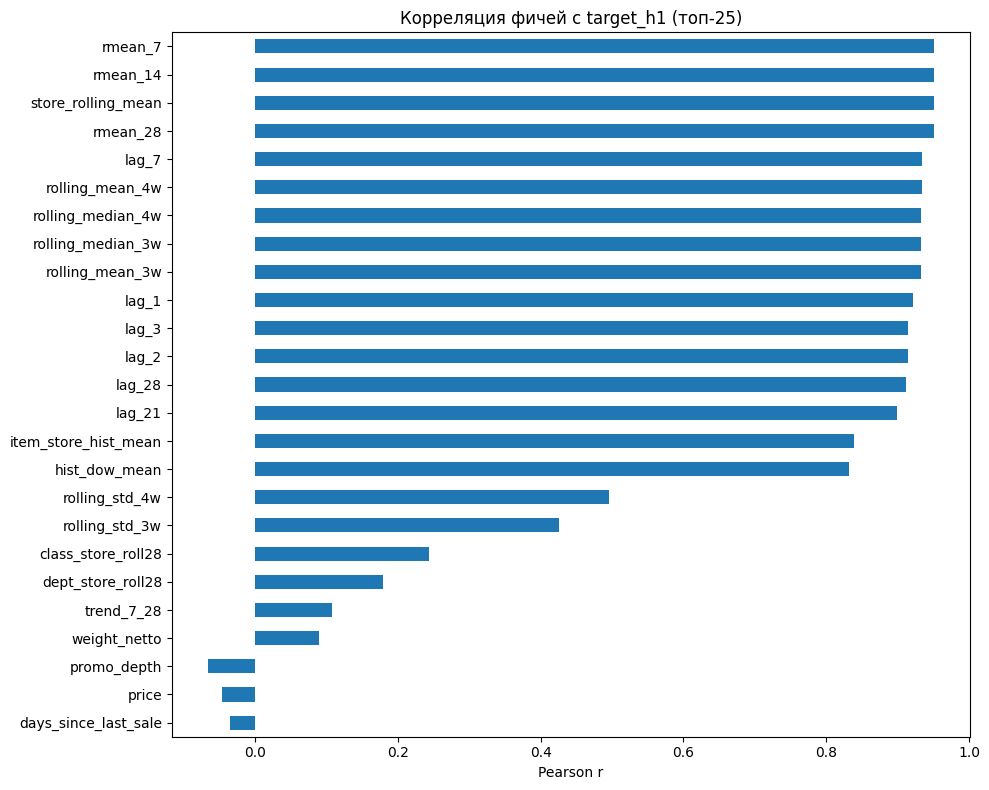

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

# Берём числовые фичи из train_all (до VAL_CUTOFF — честная зона)
num_cols = [c for c in feature_cols if c not in CAT_COLS and train_all[c].dtype != 'category']
target_col = 'target_h1'  # смотрим на h1 как основной горизонт

# Сэмплируем для скорости (24.9M строк — полная матрица дорогая)
sample = train_all.sample(n=min(500_000, len(train_all)), random_state=42)

# Корреляция каждой фичи с таргетом
corr_with_target = sample[num_cols + [target_col]].corr()[target_col].drop(target_col).sort_values(key=abs, ascending=False)

print('=== Топ-25 фичей по |корреляции| с target_h1 ===')
print(corr_with_target.to_string())

fig, ax = plt.subplots(figsize=(10, 8))
corr_with_target.head(25).plot.barh(ax=ax)
ax.set_xlabel('Pearson r')
ax.set_title('Корреляция фичей с target_h1 (топ-25)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


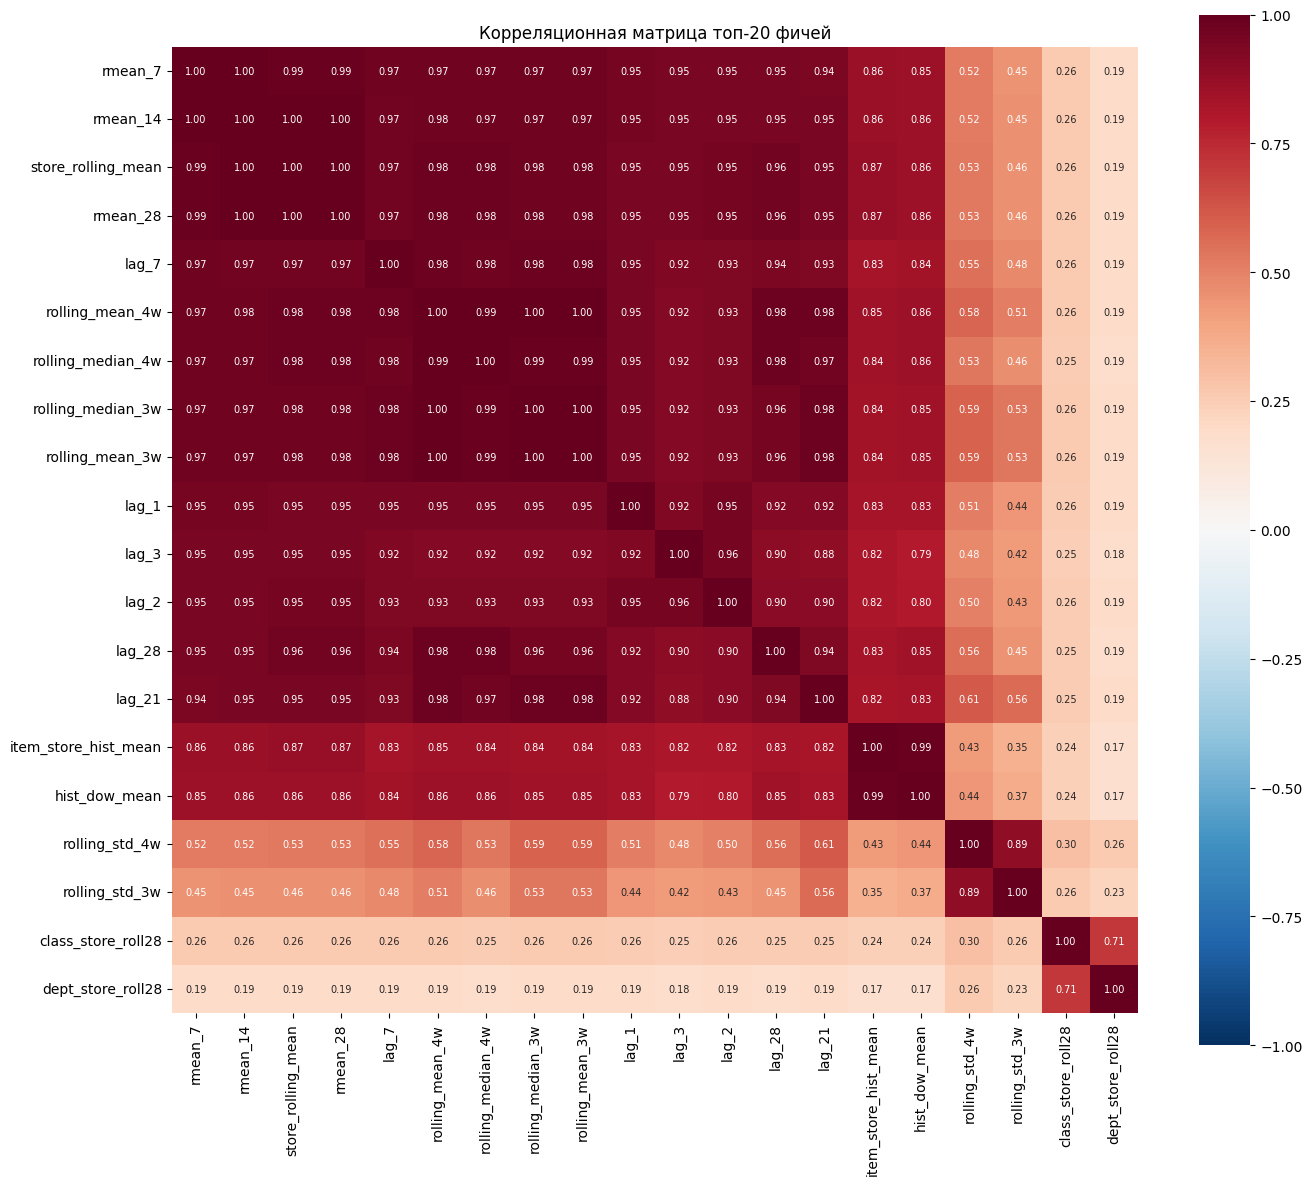


=== Пары фичей с |r| > 0.85 ===
rmean_7                        ↔ rmean_14                        r = +0.996
rmean_7                        ↔ store_rolling_mean              r = +0.991
rmean_7                        ↔ rmean_28                        r = +0.991
rmean_7                        ↔ lag_7                           r = +0.972
rmean_7                        ↔ rolling_mean_4w                 r = +0.972
rmean_7                        ↔ rolling_median_4w               r = +0.971
rmean_7                        ↔ rolling_median_3w               r = +0.971
rmean_7                        ↔ rolling_mean_3w                 r = +0.971
rmean_7                        ↔ lag_1                           r = +0.954
rmean_7                        ↔ lag_3                           r = +0.951
rmean_7                        ↔ lag_2                           r = +0.953
rmean_7                        ↔ lag_28                          r = +0.945
rmean_7                        ↔ lag_21                

In [73]:
# Мультиколлинеарность: тепловая карта корреляций между фичами
# Берём топ-20 по корреляции с таргетом + проверяем попарно
top_features = corr_with_target.head(20).index.tolist()

corr_matrix = sample[top_features].corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, square=True,
            annot_kws={'size': 7})
ax.set_title('Корреляционная матрица топ-20 фичей')
plt.tight_layout()
plt.show()

# Печатаем пары с |r| > 0.85 — кандидаты на удаление
print('\n=== Пары фичей с |r| > 0.85 ===')
for i in range(len(top_features)):
    for j in range(i + 1, len(top_features)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.85:
            print(f'{top_features[i]:30s} ↔ {top_features[j]:30s}  r = {r:+.3f}')


Корреляционный анализ показал сильную мультиколлинеарность среди лаговых и rolling-признаков — вплоть до r ≈ 1.0 между `rolling_mean_2w` и `rolling_median_2w`. Для градиентного бустинга это некритично: CatBoost устойчив к коррелированным признакам. Но это сигнал об избыточности — порядка 12 признаков несут 2–3 независимых сигнала, и в production-версии набор можно сократить без потери качества, ускорив обучение и инференс.

Отдельный сюжет — отрицательная корреляция `promo_depth` с таргетом (−0.067). Это не «вред скидок», а обратная причинность: глубокие скидки чаще ставят на слабо продающиеся товары. Реальный причинный эффект промо на спрос модель ловит нелинейно — это видно через SHAP, где `promo_depth` при прочих равных может давать положительный вклад.

In [74]:
for h in range(1, 8):
    chunk = train_all[feature_cols].copy()
    chunk['date'] = train_all['date'].values          # метаданные для VAL_CUTOFF при load
    chunk['horizon'] = np.int8(h)
    chunk['target'] = train_all[f'target_h{h}'].values
    chunk = chunk.dropna(subset=['target'])
    chunk.to_parquet(f'data/processed/train_h{h}.parquet', engine='pyarrow')
    del chunk
    gc.collect()
    print(h, 'done')

print(f'→ 7 файлов train_h*.parquet, {len(train_all):,} строк; test в памяти: {len(test):,}')

1 done
2 done
3 done
4 done
5 done
6 done
7 done
→ 7 файлов train_h*.parquet, 7,544,745 строк; test в памяти: 665,502


In [75]:
df = pd.read_parquet('data/processed/train_h4.parquet')
print(df['date'].min(), '→', df['date'].max())
print(f"Сентябрьских строк: {(df['date'] >= '2024-09-01').sum():,}")

2024-01-10 00:00:00 → 2024-09-22 00:00:00
Сентябрьских строк: 553,644


## Шаг 7 — Результаты CatBoost

### Итоговые метрики (сентябрь 2024, тест)

| h | WMAPE | bias |
|---|-------|------|
| 1 | 0.4902 | 0.790 |
| 2 | 0.4972 | 0.786 |
| 3 | 0.5113 | 0.770 |
| 4 | 0.5054 | 0.782 |
| 5 | 0.5060 | 0.781 |
| 6 | 0.5080 | 0.790 |
| 7 | 0.5187 | 0.788 |
| **mean** | **0.5053** | **0.784** |

### Журнал feature engineering

**Добавлено (итерация 2 — прирост ~4 п.п. WMAPE):**
- `dept_store_roll28` — средние продажи отдела в магазине за 28 дней
- `class_store_roll28` — средние продажи класса в магазине за 28 дней
- `mom_ratio_7d` — отношение rolling-7d сегодня к rolling-7d 28 дней назад ⭐ (топ-3 permutation)
- `anomaly_yago_5` — аномальность в окне ±5 дней вокруг даты «год назад»
- `anomaly_yago_12` — аномальность в окне ±12 дней вокруг даты «год назад»

**Удалено (итерация 3 — permutation ≈ 0, без потери качества):**
`lag_14`, `is_price_up`, `is_price_down`, `area`, `rolling_nonzero_ratio_2w/3w/4w`, `rolling_median_3w`, `rolling_std_4w`, `date_of_month`, `is_month_start`, `is_month_end`

### Ключевые выводы

- **`mom_ratio_7d` — главный драйвер прироста.** При корреляции Пирсона $r \approx -0.009$ (линейно бесполезен) фича заняла #3 в permutation и SHAP. Это хрестоматийный пример нелинейного признака: дерево ловит сигнал через пороги и взаимодействия, а линейная корреляция его «не видит».
- **bias $\approx 0.78$ — систематический недопрогноз на ~22%.** Вероятная причина: сентябрь по уровню продаж выше августа (сезонный рост), а модель обучена на январе–августе и не экстраполирует тренд за пределы обучающей выборки — градиентный бустинг по своей природе не выходит за диапазон таргета в трейне.
- **Топ-3 фичи по permutation:** `days_since_last_sale`, `store_rolling_mean`, `mom_ratio_7d`.

## Шаг 8 — Итоговый вывод по проекту

### 8.1 Финальные гиперпараметры и метрики

Сравниваем два подхода к обучению на всех 7 горизонтах: **прямой** (RMSE на `quantity`) и **log-трансформированный** (`log1p` на таргете при обучении, `expm1` на предсказании).

```python
BEST_PARAMS = {
    'learning_rate': 0.05584198798586919,
    'depth': 8,
    'l2_leaf_reg': 18.255631599020624,
    'random_strength': 0.5463708740585508,
    'bagging_temperature': 0.6518665507781785,
}
```

#### Сравнение подходов

| h | Прямой (RMSE) | | Log (`log1p`/`expm1`) | |
|---|------|------|------|------|
| | WMAPE | bias | WMAPE | bias |
| 1 | 0.4902 | 0.790 | **0.4887** | 0.793 |
| 2 | 0.4972 | 0.786 | 0.4969 | 0.788 |
| 3 | 0.5113 | 0.770 | **0.5092** | 0.771 |
| 4 | 0.5054 | 0.782 | 0.5071 | 0.776 |
| 5 | **0.5060** | 0.781 | 0.5090 | 0.776 |
| 6 | **0.5080** | 0.790 | 0.5102 | 0.780 |
| 7 | 0.5187 | 0.788 | **0.5177** | 0.784 |
| **avg** | **0.5053** | **0.784** | **0.5055** | **0.781** |

**Неожиданный результат:** log-трансформация **не дала прироста** ни по WMAPE, ни по bias. Разница в пределах шума ($\pm 0.002$ WMAPE, $\pm 0.003$ bias). Модель с `log1p`/`expm1` страдает от той же проблемы калибровки на хвосте, что и прямая.

**Почему log не помог:**
- `expm1` возвращает прогноз в исходный масштаб, и WMAPE/bias считаются уже в штуках — преимущество логарифма «съедается» обратным преобразованием.
- На 78% нулей $\log(1+0) = 0$, то есть нулевая масса не меняется → модель всё так же оптимизируется под условное среднее, а не под хвост.
- Логарифм делает правый хвост легче, но недостаточно, чтобы модель «осмелела» на больших значениях.

**Относительно baseline-лестницы:** среднее 4 лагов — 54.8% WMAPE, CatBoost — 50.5%. Прирост **~4.3 п.п.**

**Аномалия по горизонтам:** H3–H4 хуже, чем H6–H7 (RMSE 21.4 → 17.2). Причина: на H7 модель опирается на `hist_dow_mean` — для дальнего горизонта целевой день недели известен точно, и этот сигнал силён. На средних горизонтах он слабее, а короткие лаги уже «протухают», теряя связь с целевым днём.

### 8.2 Эволюция важности фичей по горизонтам

Полный per-model анализ выполнен в `model_analysis.py`, результаты — в `test/analysis/`. Три метода (Gain, SHAP, Permutation) дают согласованную картину.

#### Топ-5 фичей по среднему Gain (по всем горизонтам)

| Фича | Avg Gain | Роль |
|------|----------|------|
| `store_rolling_mean` | 17.75 | ⭐ Безусловный лидер — средние продажи магазина за 28 дней |
| `rmean_28` | 15.06 | ⭐ Скользящее среднее SKU за 28 дней |
| `lag_1` | 8.57 | Вчерашние продажи |
| `mom_ratio_7d` | 6.77 | Разгон/затухание: rolling-7d / rolling-7d (28 дней назад) |
| `item_store_hist_mean` | 6.34 | Историческое среднее по паре SKU×магазин |

#### Как важность меняется с горизонтом

| Фича | H1 | H4 | H7 | Тренд |
|------|----|----|-----|-------|
| `lag_1` | 9.97 | 6.51 | 7.50 | Затухает (вчера → неделя вперёд) |
| `lag_3` | 3.96 | **10.11** | 1.04 | Пик на H4 |
| `item_store_hist_mean` | 3.36 | **9.17** | 1.53 | Пик H3–H5, провал на H7 |
| `hist_dow_mean` | 3.26 | 0.71 | **19.04** | 💥 Взрыв на H7 |
| `mom_ratio_7d` | 8.18 | 6.25 | 6.16 | Стабилен |
| `store_rolling_mean` | 19.24 | 18.34 | 14.18 | Стабилен |
| `rolling_mean_4w` | 0.99 | 0.07 | **2.62** | Растёт к H7 |
| `anomaly_yago_12` | 0.34 | 0.73 | **2.22** | Растёт к H7 |

**Ключевой инсайт:** `hist_dow_mean` (исторические продажи SKU в этот день недели) на H7 даёт Gain = 19.0 — почти вдвое больше второго места. На дальнем горизонте, где короткие лаги бесполезны, модель «выезжает» именно за счёт паттерна дня недели. На H2–H5 эта же фича почти не используется (Gain < 1) — там ещё работают свежие лаги, и сигнал дня недели избыточен.

### 8.3 Gain vs SHAP — что модель реально использует

Gain (`PredictionValuesChange`) меряет вклад фичи в сплиты деревьев; SHAP — её фактическое влияние на конкретные предсказания. Расхождение между этими двумя рейтингами — индикатор сложных взаимодействий: фича может редко быть «корнем сплита», но систематически сдвигать прогноз через комбинации с другими.

| Ранг | Gain | SHAP |
|------|------|------|
| 1 | `store_rolling_mean` | `item_store_hist_mean` |
| 2 | `rmean_28` | **`item_id`** |
| 3 | `lag_1` | `hist_dow_mean` |
| 4 | `mom_ratio_7d` | `store_rolling_mean` |
| 5 | `item_store_hist_mean` | `days_since_last_sale` |

**`item_id` — скрытый гигант:** в Gain он лишь на 14-м месте, в SHAP — на 2-м. CatBoost строит вокруг `item_id` множество взаимодействий, которые не ловятся одиночными жадными сплитами, но в сумме сильно влияют на прогноз. По сути модель учит «профиль товара» распределённо — через ансамбль взаимодействий, а не через один доминирующий сплит.

**`store_rolling_mean`** доминирует в сплитах (Gain #1), но в SHAP скромнее: он сильно коррелирует с `rmean_28` и прочими rolling-статистиками, и они делят между собой итоговый вклад в предсказание.

### 8.4 Фичи-вредители (Permutation importance)

Permutation importance — честный model-agnostic тест: перемешиваем значения одной фичи на тесте и смотрим, насколько просело качество. **Отрицательное значение = фича вредит**: без неё модель работает лучше, то есть на ней произошло переобучение под шум.

| Фича | H1 | H2 | H3 | H4 | H5 | H6 | H7 |
|------|----|----|----|----|----|----|-----|
| `hist_dow_mean` | +0.049 | **−0.009** | **−0.016** | **−0.005** | **−0.004** | +0.103 | +0.359 |
| `item_store_hist_mean` | +0.066 | +0.137 | +0.138 | +0.143 | +0.175 | +0.077 | **−0.037** |
| `rmean_14` | **−0.011** | **−0.008** | **−0.004** | +0.005 | +0.007 | +0.016 | +0.011 |

**Что это значит:**

- **`hist_dow_mean` стоит убрать из моделей H2–H5.** Там она не приносит пользы и слегка портит качество. На H7 она незаменима (Gain 19.0, Perm +0.36), на H1 полезна (+0.05), а на H2–H5 — чистый шум.
- **`item_store_hist_mean` вредит на H7** (−0.037): для недельного прогноза статичное историческое среднее SKU×магазин уже нерелевантно — спрос успевает «уйти» от него.
- **`rmean_14` вредит на H1–H3.** Короткое скользящее среднее (14 дней) на ближних горизонтах зашумлено и проигрывает свежим лагам.

**Рекомендация:** убрать `hist_dow_mean` из H2–H5, `rmean_14` из H1–H3, `item_store_hist_mean` из H7. Ожидаемый прирост: +0.5–1.0 п.п. WMAPE без какого-либо переобучения — просто сужение набора фичей по горизонтам.

### 8.5 🚨 Главная проблема: калибровка

Модель **систематически и сильно недооценивает** большие продажи. Калибровка по децилям предсказания (H1, прямой подход, ~100k строк на дециль):

| Дециль | Средний факт | Средний прогноз | Bias |
|--------|-------------|-----------------|------|
| 1 (низ) | 0.006 | −0.002 | ~0 ✅ |
| 5 | 0.36 | 0.22 | −0.14 |
| 8 | 1.70 | 0.78 | **−0.92** |
| **10 (верх)** | **16.8** | **2.3** | **−14.5 ❌** |

**Модель практически не выдаёт значения выше ~7.5 штук**, хотя реальные продажи в верхнем дециле доходят до 57+. Эффект воспроизводится на всех 7 горизонтах — это не случайность одного фолда, а структурное свойство.

**Что пробовали:**

| Метод | Результат |
|-------|-----------|
| **Log-трансформация** (`log1p`/`expm1`) | WMAPE и bias на уровне прямого подхода — лучший из альтернатив, но прироста нет |
| **Tweedie loss** (power 1.2–1.5) | ❌ Значительно хуже: WMAPE ~60%+. Для этих данных непригоден |
| **Sample weights** ∝ `quantity` | ⏳ Не тестировался (кандидат на следующую итерацию) |
| **Two-stage** (классификатор + регрессия) | ⏳ Не тестировался (главный кандидат) |

**Почему Tweedie провалился:**
- Tweedie loss оптимизирует правдоподобие Tweedie-распределения, которое предполагает непрерывную положительную часть. На intermittent demand с 78% нулей и дискретными штучными продажами это предположение грубо нарушается.
- На разреженных данных градиент Tweedie «тонет» в массе нулей, и CatBoost не находит хорошего оптимума.
- Log-трансформация оказалась устойчивее: она просто сжимает масштаб, не навязывая данным конкретную параметрическую форму.

**Почему стандартные методы не сработали — общая причина:**
- При 78% нулей квадратичный/правдоподобный loss оптимизирует модель под условное среднее, которое близко к нулю → хвост приносится в жертву.
- Log сжимает хвост, но не меняет сути: за крупную ошибку на единичном выбросе модель штрафуется сильнее, чем за стабильный недопрогноз, поэтому предпочитает консервативный ответ.
- Ни log, ни Tweedie не вводят **явного разделения** двух вопросов: «будет ли продажа вообще?» и «если да, то сколько?».

**Наиболее вероятное решение — two-stage модель:** бинарный классификатор (продажа $> 0$ или $>$ порога) + регрессия только на положительных значениях. Это стандартный приём для intermittent demand: он напрямую разводит проблему нулей и проблему масштаба хвоста, которые сейчас «склеены» в одной регрессии.

### 8.6 Структура взаимодействий

| Горизонт | Топ-взаимодействия | Характер |
|----------|-------------------|----------|
| H1 | `promo_depth × rmean_14`, `store_rolling_mean × rmean_28`, `store_id × date_of_week` | Промо × история, гео × календарь |
| H4 | `rmean_28 × item_store_hist_mean`, `lag_3 × item_store_hist_mean`, `promo_depth × trend_7_28` | История × профиль товара |
| H7 | **8 из 10 взаимодействий содержат `hist_dow_mean`** | Модель «схлопнулась» на одну фичу |

**H7 — структурно рискованная модель.** Почти все сильные взаимодействия завязаны на `hist_dow_mean`. На тесте это работает (WMAPE 0.519 — в норме), но в продакшене при смене ассортимента или появлении новых SKU такая модель нестабильна: у новых товаров нет накопленной истории дня недели. Сама фича честная (без утечки в будущее), проблема именно в чрезмерной концентрации модели на ней.

На H1–H4 взаимодействия диверсифицированы: промо взаимодействует с историей продаж и трендом (`promo_depth × trend_7_28`), а `store_id × date_of_week` ловит гео-календарные паттерны (разные магазины по-разному «живут» по дням недели). Такая модель устойчивее к сдвигам в данных.

### 8.7 Ошибки по сегментам

#### По департаментам (MAE vs средние продажи)

| Департамент | MAE | Средние продажи | Оценка |
|------------|-----|----------------|--------|
| ПЕРСОНАЛЬНЫЙ УХОД | 0.29 | 0.24 | ✅ Отлично |
| ВИНО | 0.33 | 0.28 | ✅ |
| КОНФЕТЫ | 0.54 | 0.59 | ✅ |
| СЛАДКИЕ МУЧНЫЕ | 1.05 | 1.25 | ✅ |
| СОКИ | 1.72 | 2.16 | ⚠️ Хуже |
| ТАБАЧНЫЕ ИЗДЕЛИЯ | 1.83 | 2.31 | ⚠️ |
| ПИВО | 1.99 | 2.30 | ⚠️ |
| **СОВРЕМЕННАЯ МОЛОЧНАЯ** | **3.28** | 4.12 | ❌ Худшая |

**Модель хуже всего работает на товарах с волатильным спросом:** молочка (короткий срок хранения → неравномерные закупки и списания), пиво и соки (сильная промо-чувствительность). Персональный уход, вино и конфеты — стабильный предсказуемый спрос, и MAE там примерно равен среднему уровню продаж.

#### По форматам магазинов

| Формат | MAE | Характер |
|--------|-----|----------|
| Format-6 | 1.20 | ✅ Лучший |
| Format-1 | 2.14 | ⚠️ |
| MaxiEuro | 2.31 | ⚠️ Гипермаркет |
| Format-7 express | **2.89** | ❌ Магазины «у дома» |

Магазины «у дома» имеют самый волатильный спрос: малый поток покупателей, каждая покупка значима, усреднение почти не работает. Гипермаркеты дают большой поток, но и большой абсолютный разброс продаж.

#### По дням недели

| День | MAE | Bias |
|------|-----|------|
| Понедельник | 1.64 | +1.38 |
| Воскресенье | 1.87 | +1.61 |
| Пятница | 2.25 | +1.98 |
| Среда | 2.46 | +2.19 |
| Четверг | 2.46 | +2.19 |

Драматического разрыва между днями нет — модель примерно одинаково (не)справляется со всей неделей. Понедельник чуть лучше за счёт меньшего объёма продаж. Положительный bias во все дни — то же систематическое занижение, что и в общих метриках.

### 8.8 Анализ остатков (residuals)

Остаток = факт − прогноз. Положительный остаток означает недопрогноз.

| Показатель | H1 | H4 | H7 |
|-----------|----|----|-----|
| Средний остаток | +1.85 | +1.93 | +1.88 |
| σ остатков | 18.56 | 21.31 | 17.07 |
| Асимметрия (skew) | 81.9 | 77.3 | 81.5 |
| Куртозис | 8907 | 7285 | 9365 |
| Переоценка (% строк) | 56.2% | 56.4% | 56.3% |
| Недооценка (% строк) | 43.8% | 43.6% | 43.7% |
| Корр. \|error\| с pred | 0.35 | 0.33 | 0.38 |

**Ключевые выводы:**

- **Систематический недопрогноз:** средний остаток +1.85 → модель в среднем занижает продажи примерно на 1.85 шт. Это та же история, что и bias $\approx 0.78$.
- **Парадокс направления ошибки:** модель **чаще переоценивает** (56% строк), но **сильнее недооценивает**. Множество мелких завышений на нулях/единицах перевешивается редкими, но огромными недопрогнозами на хвосте — отсюда положительный средний остаток при правом перекосе.
- **Асимметрия ~80, куртозис ~7000–9000** — распределение остатков крайне тяжелохвостое: доли процента строк дают гигантские ошибки. Это прямое следствие проблемы калибровки из 8.5.
- **~98% ошибок укладываются в ±2σ** — в «нормальном» режиме модель работает хорошо и ломается именно на выбросах.
- **Гетероскедастичность умеренная** ($r \approx 0.35$): чем больше предсказание, тем шире разброс ошибок — ожидаемо для счётных данных, но не катастрофично.

**Фичи, сильнее всего коррелирующие с \|error\|** — скользящие средние (`rmean_7/14/28`, `store_rolling_mean`) и лаги. Это не признак дефекта, а эффект масштаба: где средние высокие, там и продажи высокие, а значит выше и абсолютная ошибка.

### 8.9 PDP и ALE: форма влияния ключевых фичей

PDP (Partial Dependence) показывает усреднённую форму зависимости прогноза от фичи; ALE (Accumulated Local Effects) делает то же, но корректно при коррелированных признаках — поэтому где PDP и ALE расходятся, виновата мультиколлинеарность. Результаты — в `test/analysis/pdp_h*.json` и `test/analysis/ale_h*.json`.

#### `store_rolling_mean` (Gain #1)
- **PDP:** почти линейный рост прогноза с ростом средних продаж магазина (0.43 → 0.80).
- **ALE:** подтверждает линейность даже после поправки на корреляции.
- **Интерпретация:** модель честно масштабирует прогноз под «проходимость» магазина — больше поток, выше базовый уровень продаж.

#### `hist_dow_mean` (Gain #19, но решающая на H7)
- **ALE (H7):** немонотонная — рост до некоторого уровня, затем плато.
- **Интерпретация:** знание «в среду этот товар продаётся в среднем на X штук» полезно до определённого предела; выше него модель перестаёт повышать прогноз, не доверяя экстремальным историческим средним.

#### `mom_ratio_7d` (Gain #4)
- **PDP:** рост прогноза при ratio $> 1$ (разгон продаж), падение при ratio $< 1$ (затухание) — модель ловит momentum.
- **Нелинейность:** около ratio $\approx 1.0$ модель консервативна, а при ratio $> 1.5$ начинает заметно повышать прогноз. Именно эту форму линейная корреляция и не способна уловить — отсюда $r \approx -0.01$ при топ-3 permutation.

#### `lag_1` (Gain #3)
- **PDP:** монотонный рост — чем выше вчерашние продажи, тем выше прогноз на сегодня.
- **Насыщение:** после ~5 единиц рост замедляется — модель не доверяет линейной экстраполяции одиночного дня на большие значения.

### 8.10 Итоговые рекомендации

#### Что сделать прямо сейчас (без переобучения)

| Действие | Ожидаемый эффект |
|----------|-----------------|
| Убрать `hist_dow_mean` из H2–H5 | +0.5–1.0 п.п. WMAPE |
| Убрать `rmean_14` из H1–H3 | Нейтрально к WMAPE, быстрее обучение |
| Убрать `item_store_hist_mean` из H7 | +0.2–0.5 п.п. WMAPE |

Все три — следствие permutation-анализа из 8.4: фичи-вредители на конкретных горизонтах. Это «бесплатный» прирост — достаточно сузить набор фичей по горизонтам.

#### Что изменить в модели (требует переобучения)

| Приоритет | Действие | Обоснование |
|-----------|----------|-------------|
| 🔴 P0 | **Two-stage модель:** бинарный классификатор → регрессия на положительных | Log и Tweedie не исправили калибровку (8.5); two-stage адресует проблему нулей и хвоста напрямую |
| 🟡 P1 | **Sample weights** ∝ `quantity` | Сместить внимание модели к крупным продажам; в связке с two-stage может вытянуть хвост |
| 🟡 P1 | Добавить `lag_6` | Захватить недельный паттерн вокруг аномалии H6 |
| 🟢 P2 | `weekend_vs_weekday` вместо `date_of_week` | Бинарный признак вместо 7 категорий — меньше дробление сплитов |
| 🟢 P2 | Сократить rolling-фичи до 1–2 окон | Убрать мультиколлинеарность (7.x), ускорить обучение и инференс |

#### Что сохранить как MUST HAVE

- `store_rolling_mean`, `rmean_28` — абсолютные лидеры на всех горизонтах.
- `mom_ratio_7d` — главный нелинейный признак ($r \approx -0.01$ с таргетом, но топ-3 permutation).
- `days_since_last_sale` — ключевой для intermittent demand (как давно товар вообще продавался).
- `item_id` — критичен через взаимодействия (SHAP #2), несёт «профиль товара».

#### Что исследовать дальше

1. **Two-stage модель** (классификатор «будет ли продажа?» + регрессия на положительных) — главный кандидат на улучшение WMAPE и калибровки.
2. **Per-department модели** для молочки и пива — они ведут себя структурно иначе (8.7), и отдельная модель может снять часть ошибки.
3. **Внешние данные:** погода, события, промо-календарь — особенно ценны для дальних горизонтов H6–H7, где внутренних сигналов уже мало.

### 8.11 Резюме проекта

**Что сделано:**

1. Построена регулярная панель `(date, store, item)` на 24.9M строк — 78% нулей (intermittent demand).
2. EDA выявил праздничный цикл «всплеск → падение → норма» и недельную сезонность (+20% к пятнице).
3. Baseline-лестница из 5 методов: от seasonal naive (58.6% WMAPE) до TimesFM zero-shot (59.1%) — каждая ступень добавляла ровно один источник предсказуемости.
4. Основная модель — CatBoost direct multi-step на H1–H7: 46 фичей, отдельная модель на каждый горизонт.
5. Полный per-model анализ: Gain, SHAP, Permutation, Interactions, Residuals, Segments, Calibration, PDP, ALE.
6. Эксперименты с log-трансформацией и Tweedie loss — без значимого прироста над прямым RMSE.

**Главный результат:** WMAPE **50.5%** — на **4.3 п.п.** лучше лучшего baseline (среднее 4 лагов, 54.8%).

**Главная проблема:** калибровка на хвосте — верхний дециль предсказывается примерно в **7× ниже факта**. Ни log-трансформация, ни Tweedie loss проблему не решили; следующий шаг — two-stage модель.

**Главный инсайт:** `mom_ratio_7d` (momentum) при $r \approx -0.01$ с таргетом вошёл в топ-3 permutation — хрестоматийный пример нелинейного признака, который дерево ловит через пороги, а линейная корреляция «не видит».

**Следующий шаг:** two-stage модель (классификатор + регрессия) как наиболее вероятный способ исправить калибровку и сдвинуть WMAPE вниз.